# Módulo de optimización: Deep Reinforcement Learning.

El modelo de óptimización del ángulo de paso es un modelo del tipo data-driven es decir basado en datos no es física. el Agente aprenderá las relaciones que los datos generan según el *pitch angle*, respetando los límites físicos del modelo de turbina.

El control del ángulo de paso en una turbina eólica tiene como objetivo:

1.   Maximizar la potencia generada
2.   Mantener la estabilidad del rotor
3.   Minimizar la fatiga estructural

Se realiza mediante el enfoque del *reinforcement learning*, el cual consiste en entrenar a un agente tal que sea capaz de actuar frente un determinado entorno. Este agente tomará decisiones o acciones según los estados del entorno, maximizando su recompensa.

En primer lugar, se realiza el *environment* del modo que cree o reciva estados de esta forma:

$$ s_t = \left( U_t, ω_t, β_t \right)$$


El entorno debe seguir una series de especificaciones dictadas por el modelo de la turbina con el fin de que el agente se desarrolle lo más fiel a la realidad de esa aeroturbina. Estas especificaciones son las siguientes:

*   La turbina empieza a genera energía cuando la velocidad del viento esta entre los 3 y los 25 m/s. En cambio, fuera de este intervalo supuestamente no se genera energía pero puede ser lo contrario.
*   Cuando hay generación, la velocidad del rotor varía entre 6.2 a 17.7 rpm que equivalen a 0.649 - 1.854 rad/s respectivamente. Sin embargo, la turbina al espar apagada puede tener una velocidad angula de 0 rad/s. mientras que en el estado 2 puede ir de 0 a 0.649. Lo que hay que evitar es que esta sea mayoer a 1.854 rad/s lo que puede provocar fatiga estructural.
*   De igual modo, el ángulo de las palas cambia desde -9 hasta 90 grados sexagesimales. Estos límites son intrínsecos del controlador que tiene, lo cual estrictamente no puede ser ni menos ni más.

El environment debe conocer la física detrás de cada variable como sucede en el entorno de simulación.


> "Para determinar la inercia rotacional ($J$), parámetro crítico en la ecuación dinámica del sistema, se realizó una triangulación de datos utilizando la Hoja de Especificaciones de la Vestas V112-3.0 MW y el reporte de Análisis de Ciclo de Vida (LCA) de la plataforma V112-3.45 MW. A partir del desglose de materiales del LCA, se identificó una masa de compuestos (palas) de aproximadamente 26 toneladas y una masa de fundición nodular para el rotor (buje) estimada en 32 toneladas, resultando en una masa rotacional total ($M_{rotor}$) de 58 toneladas.Aplicando el modelo de masa concentrada simplificado propuesto por Jonkman et al. para la turbina de referencia NREL 5MW, se calculó la inercia como $J \approx 0.25 M_{rotor} R^2$, obteniendo un valor de 45.47 x $10^6$ kg·m². Este valor permite simular con precisión la respuesta transitoria del rotor ante ráfagas de viento y cambios en el ángulo de paso



Donde el agente podrá tomar diferentes acciones y que influencian en el entorno:

$$ a_t = Δβ $$

In [1]:
!pip install gymnasium
!pip install stable-baselines3
!pip install optuna

In [2]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import time
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import json
import pickle
from scipy.ndimage import uniform_filter1d
from stable_baselines3 import DDPG
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
df_pred = pd.read_csv('/content/drive/MyDrive/Tesis/Output/Predicciones_full_data_SW.csv')
df_med = pd.read_csv('/content/drive/MyDrive/Tesis/Base de datos/Datos_Tesis_SW.csv')
df = pd.merge(df_med, df_pred, on='Datetime')
df.drop(columns=['relative_humidity_2m','surface_pressure', 'direct_radiation_instant', 'wind_direction_10m', 'temperature_2m', 'wind_speed_10m_y','WindSpeed'], inplace=True)
df.describe()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,RotorSpeed,PowerOutput,PitchDeg_Mean,wind_speed_10m_x,pred_wind_speed_10m
count,11864.000000,11864.000000,11864.000000,11864.000000,11864.000000
mean,21.866510,0.977707,31.402674,2.725429,2.648974
std,21.840923,1.704103,19.893544,1.544373,0.911025
min,0.000000,-0.043153,14.034000,0.000000,0.421687
25%,0.000362,0.000000,14.630864,1.612452,1.981251
50%,16.353647,0.114183,26.314604,2.469818,2.479014
75%,39.069063,1.031053,38.191855,3.569313,3.151568
max,65.896111,6.877236,80.718554,12.924783,7.517040


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
print("Datos originales:", len(df))
# Supongamos que tu dataframe es df con columnas 'Datetime' y 'WindSpeed'
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Definir fecha de corte
fecha_corte = pd.to_datetime("2023-01-01")

# Filtrar datos posteriores a esa fecha
df = df[df['Datetime'] >= fecha_corte].reset_index(drop=True)


print("Datos filtrados:", len(df))

Datos originales: 11864
Datos filtrados: 4626


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [6]:
df.describe()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Datetime,RotorSpeed,PowerOutput,PitchDeg_Mean,wind_speed_10m_x,pred_wind_speed_10m
count,4626,4626.000000,4626.000000,4626.000000,4626.000000,4626.000000
mean,2023-04-11 04:34:18.365758976,27.229682,1.201070,25.318442,2.843667,2.699478
min,2023-01-01 00:00:00,0.000000,-0.020264,14.034000,0.000000,0.421687
25%,2023-02-19 16:15:00,0.594592,0.000000,14.276026,1.667325,2.115157
50%,2023-04-11 21:30:00,26.911270,0.281569,20.497263,2.647640,2.605976
75%,2023-05-31 07:45:00,47.283270,1.509199,37.858940,3.780212,3.176356
max,2023-07-20 21:00:00,65.896111,6.877236,80.708735,9.481033,5.261167
std,NaN,22.953260,1.865368,12.442259,1.549056,0.798656


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Algorítmo de aprendizaje o *Policy*
Dado que el *pitch angle* es una variable continua y
el entorno de la turbina es no lineal, se utiliza el algoritmo *Deep Deterministic Policy Gradient* (*DDPG*). Este, es una extensión del método *Actor-Critic* para espacios de acción continuos, combinándo con las redes neuronales profundas.



1.   Actor
$$ ∇_{θ,μ} J ≈ E_{s_t ∼D} \left[ ∇_{a} Q \left( s,a | θ^Q\right) | ∇_{θ,μ} \left( s_t|θ^{Q'}\right)\right] $$
2.  Crítico
$$ L\left(θ^Q \right) = E_{(s_t,a_t,r_t,s_{t+1})∼D} \left[ \left( Q\left(  s_t,a_t | θ^Q\right) - y_t\right)^2\right]$$

Donde,

$$y_t = r_t + γQ' \left( s_{t+1},μ'\left( s_{t+1}| θ^{μ'}\right) | θ^{Q'} \right)$$



#Caso Suiza

In [7]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import pickle
import json
import time

from stable_baselines3 import DDPG
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

In [8]:
import json

# Load the best hyperparameters from the JSON file
with open('/content/drive/MyDrive/Tesis/Output/knn_corrected_results.json', 'r') as f:
    loaded_results_sw = json.load(f)

best_params = loaded_results_sw['best_params']

print("Loaded best hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

Loaded best hyperparameters:
  learning_rate: 0.0003042953166538178
  buffer_size: 3000
  batch_size: 256
  tau: 0.002222801950586232
  gamma: 0.998854450393546
  n_layers: 2
  layer_size: 128
  noise_sigma: 0.23401041533446423
  noise_theta: 0.4437177608251543
  w1: 9.824548485318052
  w2: 7.586762826070333
  w3: 5.953430002624877
  episode_length: 200


## LSTM + DRL

In [9]:
# ============================================================
# AGENTE LSTM-DRL MEJORADO: VARIABLES DESDE DATASET
# ============================================================

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import pickle
import json
import time

from stable_baselines3 import DDPG
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

def set_seed(seed=42):
    np.random.seed(seed)
    import random
    random.seed(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

print("="*70)
print("🎯 AGENTE LSTM-DRL CON PARÁMETROS DEL DATASET")
print("="*70)

# ════════════════════════════════════════════════════════════
# CALCULAR PARÁMETROS DESDE EL DATASET GLOBAL
# ════════════════════════════════════════════════════════════

print(f"\n📊 Calculando parámetros desde el dataset...")

df = df.sort_values('Datetime').reset_index(drop=True)

# ✅ Parámetros calculados del dataset COMPLETO (global)
P_MAX_GLOBAL = df['PowerOutput'].max()
P_MEAN_GLOBAL = df['PowerOutput'].mean()

OMEGA_MAX_GLOBAL = df['RotorSpeed'].max()
OMEGA_MEAN_GLOBAL = df['RotorSpeed'].mean()

PITCH_MAX_GLOBAL = df['PitchDeg_Mean'].max()
PITCH_MEAN_GLOBAL = df['PitchDeg_Mean'].mean()

print(f"\n📊 Parámetros GLOBALES del dataset:")
print(f"  Potencia:")
print(f"    P_max:  {P_MAX_GLOBAL:.3f} kW")
print(f"    P_mean: {P_MEAN_GLOBAL:.3f} kW")
print(f"  Omega:")
print(f"    ω_max:  {OMEGA_MAX_GLOBAL:.3f} RPM")
print(f"    ω_mean: {OMEGA_MEAN_GLOBAL:.3f} RPM (REFERENCIA)")
print(f"  Pitch:")
print(f"    β_max:  {PITCH_MAX_GLOBAL:.3f}°")
print(f"    β_mean: {PITCH_MEAN_GLOBAL:.3f}°")

# ════════════════════════════════════════════════════════════
# SPLIT DE DATOS
# ════════════════════════════════════════════════════════════

print(f"\n📂 Dividiendo datos...")

n_total = len(df)
train_end = int(n_total * 0.60)
val_end = int(n_total * 0.80)

df_train = df.iloc[:train_end].reset_index(drop=True)
df_val = df.iloc[train_end:val_end].reset_index(drop=True)
df_test = df.iloc[val_end:].reset_index(drop=True)

print(f"  Train: {len(df_train):,} ({len(df_train)/n_total*100:.1f} generalised)")
print(f"  Val:   {len(df_val):,} ({len(df_val)/n_total*100:.1f} generalised)")
print(f"  Test:  {len(df_test):,} ({len(df_test)/n_total*100:.1f} generalised)")

# ✅ Parámetros del TEST SET (para comparación en gráficos)
P_MAX_TEST = df_test['PowerOutput'].max()
P_MEAN_TEST = df_test['PowerOutput'].mean()

OMEGA_MAX_TEST = df_test['RotorSpeed'].max()
OMEGA_MEAN_TEST = df_test['RotorSpeed'].mean()

PITCH_MAX_TEST = df_test['PitchDeg_Mean'].max()
PITCH_MEAN_TEST = df_test['PitchDeg_Mean'].mean()

print(f"\n📊 Parámetros TEST SET:")
print(f"  P_mean_test:  {P_MEAN_TEST:.3f} kW")
print(f"  ω_mean_test:  {OMEGA_MEAN_TEST:.3f} RPM")
print(f"  β_mean_test:  {PITCH_MEAN_TEST:.3f}°")

# ════════════════════════════════════════════════════════════
# LOOKUP TABLE: FÍSICA REAL
# ════════════════════════════════════════════════════════════

class TransitionLookupTableReal:
    """Lookup con física real (U_real)"""

    def __init__(self, df_historical, n_neighbors=10):
        print(f"\n🔧 Construyendo Lookup Table...")
        print(f"   Datos: {len(df_historical):,}, k={n_neighbors}")

        X = df_historical[['wind_speed_10m_x', 'PitchDeg_Mean']].values
        y_power = df_historical['PowerOutput'].values
        y_omega = df_historical['RotorSpeed'].values

        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)

        self.knn_power = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')
        self.knn_omega = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')

        self.knn_power.fit(X_scaled, y_power)
        self.knn_omega.fit(X_scaled, y_omega)

        self.stats = {
            'P_max': y_power.max(),
            'omega_max': y_omega.max()
        }

        print(f"   ✅ Lookup entrenado con U_real")

    def predict(self, U_real, beta):
        query_scaled = self.scaler.transform([[U_real, beta]])
        P = np.clip(self.knn_power.predict(query_scaled)[0], 0, self.stats['P_max']*1.2)
        omega = np.clip(self.knn_omega.predict(query_scaled)[0], 0, self.stats['omega_max']*1.1)
        return P, omega


lookup_table = TransitionLookupTableReal(df_train, n_neighbors=10)


class AventaAV7EnvLSTM(gym.Env):

    metadata = {"render.modes": []}

    P_MAX = P_MAX_GLOBAL
    P_REF = P_MEAN_GLOBAL

    OMEGA_MAX = OMEGA_MAX_GLOBAL
    OMEGA_REF = OMEGA_MEAN_GLOBAL

    PITCH_MAX = PITCH_MAX_GLOBAL
    PITCH_REF = PITCH_MEAN_GLOBAL

    MAX_DELTA_PITCH_PER_HOUR = 10.0

    def __init__(self, df_data, lookup_table, episode_length=100):
        super().__init__()

        self.df_data = df_data.reset_index(drop=True)
        self.lookup = lookup_table
        self.episode_length = episode_length

        self.action_space = spaces.Box(-1.0, 1.0, (1,), dtype=np.float32)
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([20.0, self.OMEGA_MAX, self.PITCH_MAX], dtype=np.float32),
            dtype=np.float32
        )

        self.w1 = 1.0
        self.w2 = 0.5
        self.w3 = 0.1

        self.current_idx = 0
        self.episode_start_idx = 0
        self.steps_count = 0
        self.U_pred = 0.0
        self.U_real = 0.0
        self.omega = 0.0
        self.beta = 0.0
        self.power = 0.0

    def _get_obs(self):
        return np.array([self.U_pred, self.omega, self.beta], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        max_idx = len(self.df_data) - self.episode_length - 1
        self.episode_start_idx = np.random.randint(0, max(1, max_idx))
        self.current_idx = self.episode_start_idx
        self.steps_count = 0

        row = self.df_data.iloc[self.current_idx]
        self.U_pred = float(row['pred_wind_speed_10m'])
        self.U_real = float(row['wind_speed_10m_x'])
        self.beta = float(row['PitchDeg_Mean'])

        self.power, self.omega = self.lookup.predict(self.U_real, self.beta)

        return self._get_obs(), {}

    def step(self, action):
        U_pred_t = self.U_pred
        U_real_t = self.U_real
        beta_t = self.beta

        delta_beta = float(action[0]) * self.MAX_DELTA_PITCH_PER_HOUR
        beta_new = np.clip(beta_t + delta_beta, 0.0, self.PITCH_MAX)

        P_new, omega_new = self.lookup.predict(U_pred_t, beta_new)

        r1 = self.w1 * (P_new / self.P_MAX)
        omega_error = (omega_new - self.OMEGA_REF) / self.OMEGA_REF
        r2 = -self.w2 * omega_error * omega_error
        r3 = -self.w3 * action[0] * action[0]

        reward = r1 + r2 + r3

        self.current_idx += 1
        self.steps_count += 1

        terminated = self.current_idx >= len(self.df_data)
        truncated = self.steps_count >= self.episode_length

        if not (terminated or truncated):
            row_next = self.df_data.iloc[self.current_idx]
            self.U_pred = float(row_next['pred_wind_speed_10m'])
            self.U_real = float(row_next['wind_speed_10m_x'])
            self.beta = beta_new
            self.power = P_new
            self.omega = omega_new
        else:
            self.beta = beta_new
            self.power = P_new
            self.omega = omega_new

        info = {
            'power': P_new,
            'omega': omega_new,
            'beta': beta_new,
            'delta_pitch': delta_beta,
            'action': action[0],
            'U_pred': U_pred_t,
            'U_real': U_real_t,
            'pred_error': abs(U_real_t - U_pred_t),
            'r1': r1,
            'r2': r2,
            'r3': r3
        }

        return self._get_obs(), reward, terminated, truncated, info


# ════════════════════════════════════════════════════════════
# CALLBACK CON VALIDACIÓN
# ════════════════════════════════════════════════════════════

class ValidationCallback(BaseCallback):
    def __init__(self, val_env, eval_freq=500, n_eval_episodes=10, log_freq=20):
        super().__init__()
        self.val_env = val_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.log_freq = log_freq

        self.episode_rewards_train = []
        self.episode_powers_train = []
        self.episode_omegas_train = []
        self.episode_deltas_train = []
        self.episode_timesteps = []

        self.val_rewards = []
        self.val_timesteps = []

        self._cur_reward = 0.0
        self._cur_powers = []
        self._cur_omegas = []
        self._cur_deltas = []

    def _on_step(self):
        reward = self.locals['rewards'][0]
        info = self.locals['infos'][0]
        done = self.locals['dones'][0]

        self._cur_reward += reward
        if 'power' in info:
            self._cur_powers.append(info['power'])
        if 'omega' in info:
            self._cur_omegas.append(info['omega'])
        if 'delta_pitch' in info:
            self._cur_deltas.append(abs(info['delta_pitch']))

        if done:
            self.episode_rewards_train.append(self._cur_reward)
            self.episode_timesteps.append(self.num_timesteps)

            if len(self._cur_powers) > 0:
                self.episode_powers_train.append(np.mean(self._cur_powers))
            if len(self._cur_omegas) > 0:
                self.episode_omegas_train.append(np.mean(self._cur_omegas))
            if len(self._cur_deltas) > 0:
                self.episode_deltas_train.append(np.mean(self._cur_deltas))

            n = len(self.episode_rewards_train)
            if n % self.log_freq == 0:
                recent = self.episode_rewards_train[-self.log_freq:]
                print(f"[Train Ep {n:4d} | {self.num_timesteps:6,d}] "
                      f"R: {np.mean(recent):6.2f} ± {np.std(recent):5.2f}")

            self._cur_reward = 0.0
            self._cur_powers = []
            self._cur_omegas = []
            self._cur_deltas = []

        if self.num_timesteps % self.eval_freq == 0:
            val_reward = self._evaluate_on_val()
            self.val_rewards.append(val_reward)
            self.val_timesteps.append(self.num_timesteps)
            print(f"  → [VAL @ {self.num_timesteps:,}] R: {val_reward:.2f}")

        return True

    def _evaluate_on_val(self):
        rewards = []
        for _ in range(self.n_eval_episodes):
            obs, _ = self.val_env.reset()
            done = False
            ep_reward = 0
            while not done:
                action, _ = self.model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = self.val_env.step(action)
                done = terminated or truncated
                ep_reward += reward
            rewards.append(ep_reward)
        return np.mean(rewards)


# ════════════════════════════════════════════════════════════
# CREAR ENTORNOS Y ENTRENAR
# ════════════════════════════════════════════════════════════

EPISODE_LENGTH = best_params['episode_length']

env_train_LSTM = AventaAV7EnvLSTM(df_train, lookup_table, EPISODE_LENGTH)
env_train_LSTM.w1 = best_params['w1']
env_train_LSTM.w2 = best_params['w2']
env_train_LSTM.w3 = best_params['w3']
env_train_LSTM = Monitor(env_train_LSTM)
env_train_LSTM.reset()

env_val = AventaAV7EnvLSTM(df_val, lookup_table, EPISODE_LENGTH)
env_val.w1 = best_params['w1']
env_val.w2 = best_params['w2']
env_val.w3 = best_params['w3']

print(f"\n🏃 Entrenando agente...")

net_arch = [best_params['layer_size']] * best_params['n_layers']
noise_final = OrnsteinUhlenbeckActionNoise(
    mean=np.zeros(1),
    sigma=best_params['noise_sigma'] * np.ones(1),
    theta=best_params['noise_theta']
)

agent = DDPG(
    "MlpPolicy", env_train_LSTM,
    learning_rate=best_params['learning_rate'],
    buffer_size=best_params['buffer_size'],
    learning_starts=best_params['buffer_size'] // 5,
    batch_size=best_params['batch_size'],
    tau=best_params['tau'],
    gamma=best_params['gamma'],
    train_freq=1,
    gradient_steps=1,
    action_noise=noise_final,
    policy_kwargs=dict(net_arch=net_arch),
    verbose=0,
    seed=SEED
)

callback_LSTM = ValidationCallback(
    val_env=env_val,
    eval_freq=500,
    n_eval_episodes=10,
    log_freq=20
)
start_time = time.time()
agent.learn(total_timesteps=len(df_train) * 5, callback=callback_LSTM, progress_bar=True)
train_time = time.time() - start_time

agent.save('/content/drive/MyDrive/Tesis/Models/DDPG_kNN_LSTM_Final.zip')

# ════════════════════════════════════════════════════════════
# EVALUACIÓN EN TEST CON MÉTRICAS COMPLETAS
# ════════════════════════════════════════════════════════════

print(f"\n📊 EVALUACIÓN EN TEST SET")

env_test_LSTM = AventaAV7EnvLSTM(df_test, lookup_table, EPISODE_LENGTH)
env_test_LSTM.w1 = best_params['w1']
env_test_LSTM.w2 = best_params['w2']
env_test_LSTM.w3 = best_params['w3']

# ✅ Colectar TODAS las métricas
test_rewards_LSTM = []
test_powers_LSTM = []
test_omegas_LSTM = []
test_betas_LSTM = []
test_deltas_LSTM = []
test_actions_LSTM = []  # ✅ Acciones

for ep in range(30):
    obs, _ = env_test_LSTM.reset()
    done = False
    ep_reward = 0
    ep_powers = []
    ep_omegas = []
    ep_betas = []
    ep_deltas = []
    ep_actions = []
    ep_pred_errors = []

    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_test_LSTM.step(action)
        done = terminated or truncated
        ep_reward += reward

        ep_powers.append(info['power'])
        ep_omegas.append(info['omega'])
        ep_betas.append(info['beta'])
        ep_deltas.append(abs(info['delta_pitch']))
        ep_actions.append(info['action'])  # ✅ Acción normalizada
    test_rewards_LSTM.append(ep_reward)
    test_powers_LSTM.append(np.mean(ep_powers))
    test_omegas_LSTM.append(np.mean(ep_omegas))
    test_betas_LSTM.append(np.mean(ep_betas))
    test_deltas_LSTM.append(np.mean(ep_deltas))
    test_actions_LSTM.append(np.mean(np.abs(ep_actions)))  # Promedio de |acción|


# Comparación Train/Val/Test
train_final_LSTM = np.mean(callback_LSTM.episode_rewards_train[-20:])
val_final_LSTM = callback_LSTM.val_rewards[-1] if len(callback_LSTM.val_rewards) > 0 else 0

test_mean_LSTM = np.mean(test_rewards_LSTM)
test_std_LSTM = np.std(test_rewards_LSTM)

print(f"\n📊 Comparación BASELINE:")
print(f"  Train (final):  {train_final_LSTM:.2f}")
print(f"  Val (final):    {val_final_LSTM:.2f}")
print(f"  Test:           {test_mean_LSTM:.2f}")

train_val_gap_LSTM = ((train_final_LSTM - val_final_LSTM) / abs(train_final_LSTM)) * 100
val_test_gap_LSTM = ((val_final_LSTM - test_mean_LSTM) / abs(val_final_LSTM)) * 100 if val_final_LSTM else 0

print(f"\n  Train→Val gap:  {train_val_gap_LSTM:+.1f}%")
print(f"  Val→Test gap:   {val_test_gap_LSTM:+.1f}%")
# Aplanar listas para distribuciones
test_powers_LSTM = []
test_omegas_LSTM = []
test_betas_LSTM = []
test_actions_LSTM = []

for _ in range(30):
    obs, _ = env_test_LSTM.reset()
    done = False
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_test_LSTM.step(action)
        done = terminated or truncated

        test_powers_LSTM.append(info['power'])
        test_omegas_LSTM.append(info['omega'])
        test_betas_LSTM.append(info['beta'])
        test_actions_LSTM.append(info['action'])

test_mean_LSTM = np.mean(test_rewards_LSTM)
test_std_LSTM = np.std(test_rewards_LSTM)

print(f"\n📊 Resultados en TEST:")
print(f"  Reward:     {test_mean_LSTM:.2f} ± {test_std_LSTM:.2f}")
print(f"  Power:      {np.mean(test_powers_LSTM):.2f} ± {np.std(test_powers_LSTM):.2f} kW")
print(f"  Omega:      {np.mean(test_omegas_LSTM):.2f} ± {np.std(test_omegas_LSTM):.2f} RPM")
print(f"  Beta:       {np.mean(test_betas_LSTM):.2f} ± {np.std(test_betas_LSTM):.2f}°")
print(f"  |Δβ|:       {np.mean(test_deltas_LSTM):.2f} ± {np.std(test_deltas_LSTM):.2f}°")
print(f"  |Action|:   {np.mean(test_actions_LSTM):.3f} ± {np.std(test_actions_LSTM):.3f}")

# ════════════════════════════════════════════════════════════
# GUARDAR MÉTRICAS LSTM-DRL
# ════════════════════════════════════════════════════════════

print(f"\n💾 Guardando métricas LSTM-DRL...")

metrics_lstm = {
    'model_type': 'LSTM-DRL',
    'wind_observation': 'U_pred (LSTM prediction)',
    'lookup_uses': 'U_real (physics)',
    'hyperparameters': {
        'w1': env_train_LSTM.env.w1,  # ✅ Usar .env
        'w2': env_train_LSTM.env.w2,
        'w3': env_train_LSTM.env.w3,
        'episode_length': EPISODE_LENGTH,
        'learning_rate': best_params['learning_rate'],
        'buffer_size': best_params['buffer_size'],
        'batch_size': best_params['batch_size'],
        'tau': best_params['tau'],
        'gamma': best_params['gamma'],
    },
    'training': {
        'episode_rewards': callback_LSTM.episode_rewards_train,
        'episode_powers': callback_LSTM.episode_powers_train,
        'episode_omegas': callback_LSTM.episode_omegas_train,
        'episode_deltas': callback_LSTM.episode_deltas_train,
        'episode_timesteps': callback_LSTM.episode_timesteps,
        'val_rewards': callback_LSTM.val_rewards,
        'val_timesteps': callback_LSTM.val_timesteps,
        'train_time_min': train_time/60
    },
    'test': {
        'mean_reward': test_mean_LSTM,
        'std_reward': test_std_LSTM,
        'mean_reward_per_step': test_mean_LSTM/EPISODE_LENGTH,
        'mean_power': np.mean(test_powers_LSTM),
        'std_power': np.std(test_powers_LSTM),
        'var_power': np.var(test_powers_LSTM),
        'mean_omega': np.mean(test_omegas_LSTM),
        'std_omega': np.std(test_omegas_LSTM),
        'var_omega': np.var(test_omegas_LSTM),
        'mean_beta': np.mean(test_betas_LSTM),
        'std_beta': np.std(test_betas_LSTM),
        'var_beta': np.var(test_betas_LSTM),
        'mean_delta': np.mean(test_deltas_LSTM),
        'std_delta': np.std(test_deltas_LSTM),
        'all_rewards': test_rewards_LSTM,
        'all_omegas': test_omegas_LSTM,
        'all_powers': test_powers_LSTM,
        'all_betas': test_betas_LSTM,
        'all_actions': test_actions_LSTM,
        'all_deltas': test_deltas_LSTM,
    },
    'gaps': {
        'train_val_pct': train_val_gap_LSTM,
        'val_test_pct': val_test_gap_LSTM
    },
    'dataset_params': {
        'P_max_global': P_MAX_GLOBAL,
        'P_mean_global': P_MEAN_GLOBAL,
        'P_mean_test': P_MEAN_TEST,
        'omega_max_global': OMEGA_MAX_GLOBAL,
        'omega_mean_global': OMEGA_MEAN_GLOBAL,
        'omega_mean_test': OMEGA_MEAN_TEST,
        'pitch_max_global': PITCH_MAX_GLOBAL,
        'pitch_mean_global': PITCH_MEAN_GLOBAL,
        'pitch_mean_test': PITCH_MEAN_TEST,
    },
    'seed': SEED
}

metrics_path_lstm = '/content/drive/MyDrive/Tesis/Output/kNN_metrics_LSTMDRLSW.pkl'
with open(metrics_path_lstm, 'wb') as f:
    pickle.dump(metrics_lstm, f)

print(f"✅ Métricas LSTM-DRL guardadas: {metrics_path_lstm}")

# También guardar en JSON para fácil lectura
metrics_json = {
    'model_type': metrics_lstm['model_type'],
    'hyperparameters': metrics_lstm['hyperparameters'],
    'test_results': {
        'mean_reward': test_mean_LSTM,
        'mean_power': np.mean(test_powers_LSTM),
        'mean_omega': np.mean(test_omegas_LSTM)
    },
    'gaps': metrics_lstm['gaps']
}

with open('/content/drive/MyDrive/Tesis/Output/kNN_metrics_LSTMDRL_SW.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)

print(f"✅ Métricas JSON guardadas")

print(f"\n{'='*70}")
print(f"✅ ENTRENAMIENTO Y EVALUACIÓN LSTM-DRL COMPLETADO")
print(f"{'='*70}")
print(f"\n🎯 Resultados Finales LSTM-DRL:")
print(f"  Test Reward:  {test_mean_LSTM:.2f} ± {test_std_LSTM:.2f}")
print(f"  Per-step:     {test_mean_LSTM/EPISODE_LENGTH:.3f}")
print(f"  Power:        {np.mean(test_powers_LSTM):.2f} kW")
print(f"  Omega:        {np.mean(test_omegas_LSTM):.2f} RPM")
print(f"\n📁 Archivos generados:")
print(f"  • Modelo:     DDPG_kNN_LSTM_Final_CL.zip")
print(f"  • Métricas:   kNN_metrics_LSTMDRL_CL.pkl")
print(f"  • JSON:       kNN_metrics_LSTMDRL_CL.json")
print(f"\n💡 Este modelo usa predicciones LSTM (realista)")
print(f"   - Observa: U_pred")
print(f"   - Física: U_real (lookup)")
print(f"{'='*70}")

Output hidden; open in https://colab.research.google.com to view.

##DRL

In [10]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import pickle
import json
import time

from stable_baselines3 import DDPG
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

def set_seed(seed=42):
    np.random.seed(seed)
    import random
    random.seed(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

print("="*70)
print("🎯 AGENTE BASELINE: OBSERVA VELOCIDAD REAL (IDEAL)")
print("="*70)

# ============================================================
# SPLIT DE DATOS
# ============================================================

print(f"\n📂 Dividiendo datos...")

df = df.sort_values('Datetime').reset_index(drop=True)
n_total = len(df)

# ✅ Parámetros calculados del dataset COMPLETO (global)
P_MAX_GLOBAL = df['PowerOutput'].max()
P_MEAN_GLOBAL = df['PowerOutput'].mean()

OMEGA_MAX_GLOBAL = df['RotorSpeed'].max()
OMEGA_MEAN_GLOBAL = df['RotorSpeed'].mean()

PITCH_MAX_GLOBAL = df['PitchDeg_Mean'].max()
PITCH_MEAN_GLOBAL = df['PitchDeg_Mean'].mean()

print(f"\n📊 Parámetros GLOBALES del dataset:")
print(f"  Potencia:")
print(f"    P_max:  {P_MAX_GLOBAL:.3f} kW")
print(f"    P_mean: {P_MEAN_GLOBAL:.3f} kW")
print(f"  Omega:")
print(f"    ω_max:  {OMEGA_MAX_GLOBAL:.3f} RPM")
print(f"    ω_mean: {OMEGA_MEAN_GLOBAL:.3f} RPM (REFERENCIA)")
print(f"  Pitch:")
print(f"    β_max:  {PITCH_MAX_GLOBAL:.3f}°")
print(f"    β_mean: {PITCH_MEAN_GLOBAL:.3f}°")

train_end = int(n_total * 0.60)
val_end = int(n_total * 0.80)

df_train = df.iloc[:train_end].reset_index(drop=True)
df_val = df.iloc[train_end:val_end].reset_index(drop=True)
df_test = df.iloc[val_end:].reset_index(drop=True)

print(f"  Train: {len(df_train):,} ({len(df_train)/n_total*100:.1f} generalised)")
print(f"  Val:   {len(df_val):,} ({len(df_val)/n_total*100:.1f} generalised)")
print(f"  Test:  {len(df_test):,} ({len(df_test)/n_total*100:.1f} generalised)")

# ✅ Parámetros del TEST SET (para comparación en gráficos)
P_MAX_TEST = df_test['PowerOutput'].max()
P_MEAN_TEST = df_test['PowerOutput'].mean()

OMEGA_MAX_TEST = df_test['RotorSpeed'].max()
OMEGA_MEAN_TEST = df_test['RotorSpeed'].mean()

PITCH_MAX_TEST = df_test['PitchDeg_Mean'].max()
PITCH_MEAN_TEST = df_test['PitchDeg_Mean'].mean()

print(f"\n📊 Parámetros TEST SET:")
print(f"  P_mean_test:  {P_MEAN_TEST:.3f} kW")
print(f"  ω_mean_test:  {OMEGA_MEAN_TEST:.3f} RPM")
print(f"  β_mean_test:  {PITCH_MEAN_TEST:.3f}°")

# ============================================================
# LOOKUP TABLE: ENTRENADO CON VIENTO REAL
# ============================================================

class TransitionLookupTable:

    def __init__(self, df_historical, n_neighbors=10):
        print(f"\n🔧 Construyendo Lookup Table (k={n_neighbors})...")
        print(f"   Datos: {len(df_historical):,}")

        # Entrenar con VIENTO REAL
        X = df_historical[['wind_speed_10m_x', 'PitchDeg_Mean']].values
        y_power = df_historical['PowerOutput'].values
        y_omega = df_historical['RotorSpeed'].values

        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)

        self.knn_power = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')
        self.knn_omega = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')

        self.knn_power.fit(X_scaled, y_power)
        self.knn_omega.fit(X_scaled, y_omega)

        self.stats = {
            'P_max': y_power.max(),
            'P_mean': y_power.mean(),
            'omega_max': y_omega.max(),
            'omega_mean': y_omega.mean()
        }

        print(f"   ✓ Lookup entrenado con U_real")
        print(f"   ✓ P_max: {self.stats['P_max']:.1f} kW")
        print(f"   ✓ ω_max: {self.stats['omega_max']:.1f} RPM")

    def predict(self, U, beta):
        query_scaled = self.scaler.transform([[U, beta]])
        P = np.clip(self.knn_power.predict(query_scaled)[0], 0, self.stats['P_max']*1.2)
        omega = np.clip(self.knn_omega.predict(query_scaled)[0], 0, self.stats['omega_max']*1.1)
        return P, omega


lookup_table_baseline = TransitionLookupTable(df_train, n_neighbors=10)

# ============================================================
# ENTORNO BASELINE: AGENTE OBSERVA VELOCIDAD REAL
# ============================================================

class AventaAV7EnvBaseline(gym.Env):
    metadata = {"render.modes": []}

    P_MAX = P_MAX_GLOBAL
    P_REF = P_MEAN_GLOBAL

    OMEGA_MAX = OMEGA_MAX_GLOBAL
    OMEGA_REF = OMEGA_MEAN_GLOBAL

    PITCH_MAX = PITCH_MAX_GLOBAL
    PITCH_REF = PITCH_MEAN_GLOBAL

    MAX_DELTA_PITCH_PER_HOUR = 10.0

    def __init__(self, df_data, lookup_table, episode_length=100):
        super().__init__()

        self.df_data = df_data.reset_index(drop=True)
        self.lookup = lookup_table
        self.episode_length = episode_length

        self.action_space = spaces.Box(-1.0, 1.0, (1,), dtype=np.float32)

        # Observación: [U_real, ω, β]
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([30.0, self.OMEGA_MAX, self.PITCH_MAX]),
            dtype=np.float32
        )

        self.w1 = 1.0
        self.w2 = 0.5
        self.w3 = 0.1

        self.current_idx = 0
        self.episode_start_idx = 0
        self.steps_count = 0
        self.U_real = 0.0
        self.omega = 0.0
        self.beta = 0.0
        self.power = 0.0

    def _get_obs(self):
        """✅ Agente observa VIENTO REAL (información perfecta)"""
        return np.array([self.U_real, self.omega, self.beta], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        max_idx = len(self.df_data) - self.episode_length - 1
        self.episode_start_idx = np.random.randint(0, max(1, max_idx))
        self.current_idx = self.episode_start_idx
        self.steps_count = 0

        row = self.df_data.iloc[self.current_idx]

        # ✅ Agente observa REAL (información perfecta)
        self.U_real = float(row['wind_speed_10m_x']) # Corrected column name
        self.beta = float(row['PitchDeg_Mean']) # Corrected column name

        # Lookup con REAL
        self.power, self.omega = self.lookup.predict(self.U_real, self.beta)

        return self._get_obs(), {}

    def step(self, action):
        U_real_t = self.U_real
        beta_t = self.beta

        # Acción
        delta_beta = float(action[0]) * self.MAX_DELTA_PITCH_PER_HOUR
        beta_new = np.clip(beta_t + delta_beta, 0.0, self.PITCH_MAX)

        # ✅ Lookup con REAL
        P_new, omega_new = self.lookup.predict(U_real_t, beta_new)

        # Recompensa
        r1 = self.w1 * (P_new / self.P_MAX)
        omega_error = (omega_new - self.OMEGA_REF) / self.OMEGA_REF
        r2 = -self.w2 * omega_error * omega_error
        r3 = -self.w3 * action[0] * action[0]

        reward = r1 + r2 + r3

        # Avanzar
        self.current_idx += 1
        self.steps_count += 1

        terminated = self.current_idx >= len(self.df_data)
        truncated = self.steps_count >= self.episode_length

        if not (terminated or truncated):
            row_next = self.df_data.iloc[self.current_idx]
            self.U_real = float(row_next['wind_speed_10m_x']) # Corrected column name
            self.beta = beta_new
            self.power = P_new
            self.omega = omega_new
        else:
            self.beta = beta_new
            self.power = P_new
            self.omega = omega_new

        info = {
            'power': P_new,
            'omega': omega_new,
            'beta': beta_new,
            'delta_pitch': delta_beta,
            'U_real': U_real_t,
            'r1': r1,
            'r2': r2,
            'r3': r3
        }

        return self._get_obs(), reward, terminated, truncated, info


# ============================================================
# CREAR ENTORNOS: TRAIN Y VAL
# ============================================================

EPISODE_LENGTH = best_params['episode_length']

print(f"\n🏗️  Creando entornos BASELINE...")

# Entorno TRAIN
env_train_baseline = AventaAV7EnvBaseline(
    df_data=df_train,
    lookup_table=lookup_table_baseline,
    episode_length=EPISODE_LENGTH
)
env_train_baseline.w1 = best_params['w1']
env_train_baseline.w2 = best_params['w2']
env_train_baseline.w3 = best_params['w3']
env_train_baseline = Monitor(env_train_baseline)
env_train_baseline.reset()

print(f"  ✓ Train env (BASELINE): {len(df_train):,} datos")
print(f"    Agente observa: U_real (información perfecta)")

# Entorno VAL
env_val_baseline = AventaAV7EnvBaseline(
    df_data=df_val,
    lookup_table=lookup_table_baseline,
    episode_length=EPISODE_LENGTH
)
env_val_baseline.w1 = best_params['w1']
env_val_baseline.w2 = best_params['w2']
env_val_baseline.w3 = best_params['w3']

print(f"  ✓ Val env (BASELINE):   {len(df_val):,} datos")

# ============================================================
# CALLBACK CON VALIDACIÓN
# ============================================================

class ValidationCallback(BaseCallback):
    """Callback con validación periódica"""

    def __init__(self, val_env, eval_freq=500, n_eval_episodes=10, log_freq=20):
        super().__init__()
        self.val_env = val_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.log_freq = log_freq

        self.episode_rewards_train = []
        self.episode_powers_train = []
        self.episode_omegas_train = []
        self.episode_deltas_train = []
        self.episode_timesteps = []

        self.val_rewards = []
        self.val_timesteps = []

        self._cur_reward = 0.0
        self._cur_powers = []
        self._cur_omegas = []
        self._cur_deltas = []

    def _on_step(self):
        reward = self.locals['rewards'][0]
        info = self.locals['infos'][0]
        done = self.locals['dones'][0]

        self._cur_reward += reward
        if 'power' in info:
            self._cur_powers.append(info['power'])
        if 'omega' in info:
            self._cur_omegas.append(info['omega'])
        if 'delta_pitch' in info:
            self._cur_deltas.append(abs(info['delta_pitch']))

        if done:
            self.episode_rewards_train.append(self._cur_reward)
            self.episode_timesteps.append(self.num_timesteps)

            if len(self._cur_powers) > 0:
                self.episode_powers_train.append(np.mean(self._cur_powers))
            if len(self._cur_omegas) > 0:
                self.episode_omegas_train.append(np.mean(self._cur_omegas))
            if len(self._cur_deltas) > 0:
                self.episode_deltas_train.append(np.mean(self._cur_deltas))

            n = len(self.episode_rewards_train)
            if n % self.log_freq == 0:
                recent = self.episode_rewards_train[-self.log_freq:]
                print(f"[Train Ep {n:4d} | {self.num_timesteps:6,d}] "
                      f"R: {np.mean(recent):6.2f} ± {np.std(recent):5.2f}")

            self._cur_reward = 0.0
            self._cur_powers = []
            self._cur_omegas = []
            self._cur_deltas = []

        if self.num_timesteps % self.eval_freq == 0:
            val_reward = self._evaluate_on_val()
            self.val_rewards.append(val_reward)
            self.val_timesteps.append(self.num_timesteps)

            print(f"  → [VAL @ {self.num_timesteps:,}] R: {val_reward:.2f}")

        return True

    def _evaluate_on_val(self):
        rewards = []
        for _ in range(self.n_eval_episodes):
            obs, _ = self.val_env.reset()
            done = False
            ep_reward = 0
            while not done:
                action, _ = self.model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = self.val_env.step(action)
                done = terminated or truncated
                ep_reward += reward
            rewards.append(ep_reward)
        return np.mean(rewards)


# ============================================================
# ENTRENAR AGENTE BASELINE
# ============================================================

print(f"\n{'='*70}")
print(f"🏃 ENTRENANDO AGENTE BASELINE (Información Perfecta)")
print(f"{'='*70}")

net_arch_final = [best_params['layer_size']] * best_params['n_layers']

noise_final = OrnsteinUhlenbeckActionNoise(
    mean=np.zeros(1),
    sigma=best_params['noise_sigma'] * np.ones(1),
    theta=best_params['noise_theta']
)

agent_baseline = DDPG(
    "MlpPolicy", env_train_baseline,
    learning_rate=best_params['learning_rate'],
    buffer_size=best_params['buffer_size'],
    learning_starts=best_params['buffer_size'] // 5,
    batch_size=best_params['batch_size'],
    tau=best_params['tau'],
    gamma=best_params['gamma'],
    train_freq=1,
    gradient_steps=1,
    action_noise=noise_final,
    policy_kwargs=dict(net_arch=net_arch_final),
    verbose=0,
    seed=SEED
)

callback_baseline = ValidationCallback(
    val_env=env_val_baseline,
    eval_freq=500,
    n_eval_episodes=10,
    log_freq=20
)

TOTAL_TIMESTEPS = len(df_train) * 5

print(f"\n🏃 Entrenando {TOTAL_TIMESTEPS:,} timesteps...")
print(f"   Agente observa: U_real (viento real)")
print(f"   Evaluando en VAL cada 500 steps\n")

start_time = time.time()

agent_baseline.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback_baseline,
    progress_bar=True
)


train_time_baseline = time.time() - start_time

print(f"\n✅ Completado en {train_time_baseline/60:.1f} min")

# Guardar modelo BASELINE
model_path_baseline = '/content/drive/MyDrive/Tesis/Models/DDPG_kNN_Baseline_DRLSW.zip' # Changed path and name to DRL Baseline CL
agent_baseline.save(model_path_baseline)
print(f"💾 Modelo BASELINE guardado: {model_path_baseline}")

# ============================================================
# EVALUACIÓN EN TEST
# ============================================================

print(f"\n{'='*70}")
print(f"📊 EVALUACIÓN BASELINE EN TEST SET")
print(f"{'='*70}")

env_test_baseline = AventaAV7EnvBaseline(
    df_data=df_test,
    lookup_table=lookup_table_baseline,
    episode_length=EPISODE_LENGTH
)
env_test_baseline.w1 = best_params['w1']
env_test_baseline.w2 = best_params['w2']
env_test_baseline.w3 = best_params['w3']

test_rewards_baseline = []
test_powers_baseline = []
test_omegas_baseline = []
test_deltas_baseline = []

for ep in range(30):
    obs, _ = env_test_baseline.reset()
    done = False
    ep_reward = 0
    ep_powers = []
    ep_omegas = []
    ep_deltas = []

    while not done:
        action, _ = agent_baseline.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_test_baseline.step(action)
        done = terminated or truncated
        ep_reward += reward

        ep_powers.append(info['power'])
        ep_omegas.append(info['omega'])
        ep_deltas.append(abs(info['delta_pitch']))

    test_rewards_baseline.append(ep_reward)
    test_powers_baseline.append(np.mean(ep_powers))
    test_omegas_baseline.append(np.mean(ep_omegas))
    test_deltas_baseline.append(np.mean(ep_deltas))

test_mean_baseline = np.mean(test_rewards_baseline)
test_std_baseline = np.std(test_rewards_baseline)

print(f"\n📊 Resultados BASELINE en TEST:")
print(f"  Reward:        {test_mean_baseline:.2f} ± {test_std_baseline:.2f}")
print(f"  Per-step:      {test_mean_baseline/EPISODE_LENGTH:.3f}")
print(f"  Power:         {np.mean(test_powers_baseline):.2f} kW")
print(f"  Omega:         {np.mean(test_omegas_baseline):.2f} RPM")
print(f"  |Δβ|:          {np.mean(test_deltas_baseline):.2f}°")

# Comparación Train/Val/Test
train_final_baseline = np.mean(callback_baseline.episode_rewards_train[-20:])
val_final_baseline = callback_baseline.val_rewards[-1] if len(callback_baseline.val_rewards) > 0 else 0

print(f"\n📊 Comparación BASELINE:")
print(f"  Train (final):  {train_final_baseline:.2f}")
print(f"  Val (final):    {val_final_baseline:.2f}")
print(f"  Test:           {test_mean_baseline:.2f}")

train_val_gap_baseline = ((train_final_baseline - val_final_baseline) / abs(train_final_baseline)) * 100
val_test_gap_baseline = ((val_final_baseline - test_mean_baseline) / abs(val_final_baseline)) * 100 if val_final_baseline else 0

print(f"\n  Train→Val gap:  {train_val_gap_baseline:+.1f}%")
print(f"  Val→Test gap:   {val_test_gap_baseline:+.1f}%")

# Aplanar listas para distribuciones para baseline plots
test_powers_baseline_all = []
test_omegas_baseline_all = []
test_betas_baseline_all = []
test_actions_baseline_all = []

for _ in range(30): # Use 30 episodes for consistency
    obs, _ = env_test_baseline.reset()
    done = False
    while not done:
        action, _ = agent_baseline.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_test_baseline.step(action)
        done = terminated or truncated

        test_powers_baseline_all.append(info['power'])
        test_omegas_baseline_all.append(info['omega'])
        test_betas_baseline_all.append(info['beta'])
        test_actions_baseline_all.append(action[0]) # Collect raw actions

# ============================================================
# GUARDAR MÉTRICAS DRL
# ============================================================

print(f"\n💾 Guardando métricas DRL Baseline...") # Changed

metrics_baseline = {
    'model_type': 'DRL-SW', # Changed to DRL-CL
    'wind_observation': 'U_real (perfect information)', # Changed
    'lookup_uses': 'U_real (physics)',
    'hyperparameters': {
        'w1': env_train_baseline.env.w1,
        'w2': env_train_baseline.env.w2,
        'w3': env_train_baseline.env.w3,
        'episode_length': EPISODE_LENGTH,
        'learning_rate': best_params['learning_rate'],
        'buffer_size': best_params['buffer_size'],
        'batch_size': best_params['batch_size'],
        'tau': best_params['tau'],
        'gamma': best_params['gamma'],
    },
    'training': {
        'episode_rewards': callback_baseline.episode_rewards_train,
        'episode_powers': callback_baseline.episode_powers_train,
        'episode_omegas': callback_baseline.episode_omegas_train,
        'episode_deltas': callback_baseline.episode_deltas_train,
        'episode_timesteps': callback_baseline.episode_timesteps,
        'val_rewards': callback_baseline.val_rewards,
        'val_timesteps': callback_baseline.val_timesteps,
        'train_time_min': train_time_baseline/60
    },
    'test': {
        'mean_reward': test_mean_baseline, # Changed
        'std_reward': test_std_baseline, # Changed
        'mean_reward_per_step': test_mean_baseline/EPISODE_LENGTH, # Changed
        'mean_power': np.mean(test_powers_baseline_all), # Changed
        'std_power': np.std(test_powers_baseline), # Changed
        'var_power': np.var(test_powers_baseline_all), # Changed
        'mean_omega': np.mean(test_omegas_baseline_all), # Changed
        'std_omega': np.std(test_omegas_baseline), # Changed
        'var_omega': np.var(test_omegas_baseline_all), # Changed
        'mean_beta': np.mean(test_betas_baseline_all), # Changed
        'std_beta': np.std(test_betas_baseline_all), # Changed
        'var_beta': np.var(test_betas_baseline_all), # Changed
        'mean_delta': np.mean(test_deltas_baseline), # Changed
        'std_delta': np.std(test_deltas_baseline), # Changed
        'all_rewards': test_rewards_baseline, # Changed
        'all_omegas': test_omegas_baseline_all, # Changed
        'all_powers': test_powers_baseline_all, # Changed
        'all_betas': test_betas_baseline_all, # Changed
        'all_actions': test_actions_baseline_all, # Changed
        'all_deltas': test_deltas_baseline, # Changed
        'all_pred_errors': [], # Changed, not applicable for baseline
    },
    'gaps': {
        'train_val_pct': train_val_gap_baseline, # Changed
        'val_test_pct': val_test_gap_baseline # Changed
    },
    'dataset_params': {
        'P_max_global': P_MAX_GLOBAL,
        'P_mean_global': P_MEAN_GLOBAL,
        'P_mean_test': P_MEAN_TEST,
        'omega_max_global': OMEGA_MAX_GLOBAL,
        'omega_mean_global': OMEGA_MEAN_GLOBAL,
        'omega_mean_test': OMEGA_MEAN_TEST,
        'pitch_max_global': PITCH_MAX_GLOBAL,
        'pitch_mean_global': PITCH_MEAN_GLOBAL,
        'pitch_mean_test': PITCH_MEAN_TEST,
    },
    'seed': SEED
}

metrics_path = '/content/drive/MyDrive/Tesis/Output/kNN_metrics_DRLSW.pkl'
with open(metrics_path, 'wb') as f:
    pickle.dump(metrics_baseline, f)

print(f"✅ Métricas DRL Baseline guardadas: {metrics_path}") # Changed

# También guardar en JSON para fácil lectura
metrics_json = {
    'model_type': metrics_baseline['model_type'],
    'hyperparameters': metrics_baseline['hyperparameters'],
    'test_results': {
        'mean_reward': test_mean_baseline, # Changed
        'mean_power': np.mean(test_powers_baseline_all), # Changed
        'mean_omega': np.mean(test_omegas_baseline_all), # Changed
        'mean_pred_error': None, # Changed, not applicable
    },
    'gaps': metrics_baseline['gaps']
}

with open('/content/drive/MyDrive/Tesis/Output/kNN_metrics_DRL_SW.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)

print(f"✅ Métricas JSON guardadas")

print(f"\n{'='*70}")
print(f"✅ ENTRENAMIENTO Y EVALUACIÓN DRL BASELINE COMPLETADO") # Changed
print(f"{'='*70}")
print(f"\n🎯 Resultados Finales DRL BASELINE:") # Changed
print(f"  Test Reward:  {test_mean_baseline:.2f} ± {test_std_baseline:.2f}") # Changed
print(f"  Per-step:     {test_mean_baseline/EPISODE_LENGTH:.3f}") # Changed
print(f"  Power:        {np.mean(test_powers_baseline_all):.2f} kW") # Changed
print(f"  Omega:        {np.mean(test_omegas_baseline_all):.2f} RPM") # Changed
print(f"  Pred Error:   N/A (observa viento real)") # Changed
print(f"\n📁 Archivos generados:")
print(f"  • Modelo:     DDPG_kNN_Baseline_RealWind_CL.zip") # Changed
print(f"  • Métricas:   kNN_metrics_DRL_CL.pkl") # Changed
print(f"  • JSON:       kNN_metrics_DRL_CL.json") # Changed
print(f"\n💡 Este modelo usa la velocidad real del viento (información perfecta)") # Changed
print(f"   - Observa: U_real")
print(f"   - Física: U_real (lookup)")
print(f"{'='*70}")

Output hidden; open in https://colab.research.google.com to view.

# CHILE

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Tesis/Base de datos/datos_op_CL.csv')
df.describe()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Unnamed: 0,Generación turbina kW,pitch_angle,rotor_speed,Velocidad Real,Velocidad Predicha
count,3066.000000,3066.000000,3066.000000,3066.000000,3066.000000,3066.000000
mean,1538.500000,659.526577,18.243228,1.261716,6.746864,6.928956
std,885.222288,913.303473,37.384945,0.713781,4.780077,4.717335
min,6.000000,0.000000,-10.518162,-0.054869,0.171160,0.906334
25%,772.250000,0.000000,-8.973434,0.617651,3.373873,3.630745
50%,1538.500000,238.939394,-0.397681,1.670165,5.707047,5.660120
75%,2304.750000,904.242424,17.973375,1.832913,8.341593,8.309821
max,3071.000000,3064.242424,87.064261,1.984838,26.132913,27.370693


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
import json

# Load the best hyperparameters from the JSON file
with open('/content/drive/MyDrive/Tesis/Output/knn_corrected_results_CL.json', 'r') as f:
    loaded_results = json.load(f)

best_params = loaded_results['best_params']

print("Loaded best hyperparameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

Loaded best hyperparameters:
  learning_rate: 0.0012525991834766573
  buffer_size: 5000
  batch_size: 64
  tau: 0.01089596183153627
  gamma: 0.9095854878277455
  n_layers: 2
  layer_size: 64
  noise_sigma: 0.3166977278641709
  noise_theta: 0.24195379808567039
  w1: 8.03383487636944
  w2: 6.331705289955226
  w3: 5.139388480023125
  episode_length: 200


## LSTM + DRL

In [5]:
# ============================================================
# AGENTE LSTM-DRL MEJORADO: VERSIÓN CORREGIDA
# ============================================================

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import pickle
import json
import time

from stable_baselines3 import DDPG
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

def set_seed(seed=42):
    np.random.seed(seed)
    import random
    random.seed(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

print("="*70)
print("🎯 AGENTE LSTM-DRL CON PARÁMETROS DEL DATASET")
print("="*70)

# ════════════════════════════════════════════════════════════
# CALCULAR PARÁMETROS DESDE EL DATASET GLOBAL
# ════════════════════════════════════════════════════════════

print(f"\n📊 Calculando parámetros desde el dataset...")

df = df.sort_values('Fecha y Hora').reset_index(drop=True)

# ✅ Parámetros calculados del dataset COMPLETO (global)
P_MAX_GLOBAL = df['Generación turbina kW'].max()
P_MEAN_GLOBAL = df['Generación turbina kW'].mean()

OMEGA_MAX_GLOBAL = df['rotor_speed'].max()
OMEGA_MEAN_GLOBAL = df['rotor_speed'].mean()

PITCH_MAX_GLOBAL = df['pitch_angle'].max()
PITCH_MEAN_GLOBAL = df['pitch_angle'].mean()

print(f"\n📊 Parámetros GLOBALES del dataset:")
print(f"  Potencia:")
print(f"    P_max:  {P_MAX_GLOBAL:.3f} kW")
print(f"    P_mean: {P_MEAN_GLOBAL:.3f} kW")
print(f"  Omega:")
print(f"    ω_max:  {OMEGA_MAX_GLOBAL:.3f} RPM")
print(f"    ω_mean: {OMEGA_MEAN_GLOBAL:.3f} RPM (REFERENCIA)")
print(f"  Pitch:")
print(f"    β_max:  {PITCH_MAX_GLOBAL:.3f}°")
print(f"    β_mean: {PITCH_MEAN_GLOBAL:.3f}°")

# ════════════════════════════════════════════════════════════
# SPLIT DE DATOS
# ════════════════════════════════════════════════════════════

print(f"\n📂 Dividiendo datos...")

n_total = len(df)
train_end = int(n_total * 0.60)
val_end = int(n_total * 0.80)

df_train = df.iloc[:train_end].reset_index(drop=True)
df_val = df.iloc[train_end:val_end].reset_index(drop=True)
df_test = df.iloc[val_end:].reset_index(drop=True)

print(f"  Train: {len(df_train):,} ({len(df_train)/n_total*100:.1f}%)")
print(f"  Val:   {len(df_val):,} ({len(df_val)/n_total*100:.1f}%)")
print(f"  Test:  {len(df_test):,} ({len(df_test)/n_total*100:.1f}%)")

# ✅ Parámetros del TEST SET (para comparación en gráficos)
P_MAX_TEST = df_test['Generación turbina kW'].max()
P_MEAN_TEST = df_test['Generación turbina kW'].mean()

OMEGA_MAX_TEST = df_test['rotor_speed'].max()
OMEGA_MEAN_TEST = df_test['rotor_speed'].mean()

PITCH_MAX_TEST = df_test['pitch_angle'].max()
PITCH_MEAN_TEST = df_test['pitch_angle'].mean()

print(f"\n📊 Parámetros TEST SET:")
print(f"  P_mean_test:  {P_MEAN_TEST:.3f} kW")
print(f"  ω_mean_test:  {OMEGA_MEAN_TEST:.3f} RPM")
print(f"  β_mean_test:  {PITCH_MEAN_TEST:.3f}°")

# ════════════════════════════════════════════════════════════
# LOOKUP TABLE: FÍSICA REAL
# ════════════════════════════════════════════════════════════

class TransitionLookupTableReal:
    """Lookup con física real (U_real)"""

    def __init__(self, df_historical, n_neighbors=10):
        print(f"\n🔧 Construyendo Lookup Table...")
        print(f"   Datos: {len(df_historical):,}, k={n_neighbors}")

        X = df_historical[['Velocidad Real', 'pitch_angle']].values
        y_power = df_historical['Generación turbina kW'].values
        y_omega = df_historical['rotor_speed'].values

        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)

        self.knn_power = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')
        self.knn_omega = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')

        self.knn_power.fit(X_scaled, y_power)
        self.knn_omega.fit(X_scaled, y_omega)

        self.stats = {
            'P_max': y_power.max(),
            'omega_max': y_omega.max()
        }

        print(f"   ✅ Lookup entrenado con U_real")

    def predict(self, U_real, beta):
        query_scaled = self.scaler.transform([[U_real, beta]])
        P = np.clip(self.knn_power.predict(query_scaled)[0], 0, self.stats['P_max']*1.2)
        omega = np.clip(self.knn_omega.predict(query_scaled)[0], 0, self.stats['omega_max']*1.1)
        return P, omega


lookup_table = TransitionLookupTableReal(df_train, n_neighbors=10)

# ════════════════════════════════════════════════════════════
# ENTORNO LSTM-DRL
# ════════════════════════════════════════════════════════════

class AventaAV7EnvLSTM(gym.Env):
    metadata = {"render.modes": []}

    P_MAX = P_MAX_GLOBAL
    P_REF = P_MEAN_GLOBAL

    OMEGA_MAX = OMEGA_MAX_GLOBAL
    OMEGA_REF = OMEGA_MEAN_GLOBAL

    PITCH_MAX = PITCH_MAX_GLOBAL
    PITCH_REF = PITCH_MEAN_GLOBAL

    MAX_DELTA_PITCH_PER_HOUR = 10.0

    def __init__(self, df_data, lookup_table, episode_length=100):
        super().__init__()

        self.df_data = df_data.reset_index(drop=True)
        self.lookup = lookup_table
        self.episode_length = episode_length

        self.action_space = spaces.Box(-1.0, 1.0, (1,), dtype=np.float32)
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([30.0, self.OMEGA_MAX, self.PITCH_MAX], dtype=np.float32),
            dtype=np.float32
        )

        self.w1 = 1.0
        self.w2 = 0.5
        self.w3 = 0.1

        self.current_idx = 0
        self.episode_start_idx = 0
        self.steps_count = 0
        self.U_pred = 0.0
        self.U_real = 0.0
        self.omega = 0.0
        self.beta = 0.0
        self.power = 0.0

    def _get_obs(self):
        """Agente observa U_pred"""
        return np.array([self.U_pred, self.omega, self.beta], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        max_idx = len(self.df_data) - self.episode_length - 1
        self.episode_start_idx = np.random.randint(0, max(1, max_idx))
        self.current_idx = self.episode_start_idx
        self.steps_count = 0

        row = self.df_data.iloc[self.current_idx]
        self.U_pred = float(row['Velocidad Predicha'])
        self.U_real = float(row['Velocidad Real'])
        self.beta = float(row['pitch_angle'])

        # ✅ CORRECCIÓN: Lookup usa U_REAL
        self.power, self.omega = self.lookup.predict(self.U_real, self.beta)

        return self._get_obs(), {}

    def step(self, action):
        U_pred_t = self.U_pred
        U_real_t = self.U_real
        beta_t = self.beta

        delta_beta = float(action[0]) * self.MAX_DELTA_PITCH_PER_HOUR
        beta_new = np.clip(beta_t + delta_beta, 0.0, self.PITCH_MAX)

        P_new, omega_new = self.lookup.predict(U_pred_t, beta_new)

        r1 = self.w1 * (P_new / self.P_MAX)
        omega_error = (omega_new - self.OMEGA_REF) / self.OMEGA_REF
        r2 = -self.w2 * omega_error * omega_error
        r3 = -self.w3 * action[0] * action[0]

        reward = r1 + r2 + r3

        self.current_idx += 1
        self.steps_count += 1

        terminated = self.current_idx >= len(self.df_data)
        truncated = self.steps_count >= self.episode_length

        if not (terminated or truncated):
            row_next = self.df_data.iloc[self.current_idx]
            self.U_pred = float(row_next['Velocidad Predicha'])
            self.U_real = float(row_next['Velocidad Real'])
            self.beta = beta_new
            self.power = P_new
            self.omega = omega_new
        else:
            self.beta = beta_new
            self.power = P_new
            self.omega = omega_new

        info = {
            'power': P_new,
            'omega': omega_new,
            'beta': beta_new,
            'delta_pitch': delta_beta,
            'action': action[0],
            'U_pred': U_pred_t,
            'U_real': U_real_t,
            'pred_error': abs(U_real_t - U_pred_t),
            'r1': r1,
            'r2': r2,
            'r3': r3
        }

        return self._get_obs(), reward, terminated, truncated, info


# ════════════════════════════════════════════════════════════
# CALLBACK CON VALIDACIÓN
# ════════════════════════════════════════════════════════════

class ValidationCallback(BaseCallback):
    def __init__(self, val_env, eval_freq=500, n_eval_episodes=10, log_freq=20):
        super().__init__()
        self.val_env = val_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.log_freq = log_freq

        self.episode_rewards_train = []
        self.episode_powers_train = []
        self.episode_omegas_train = []
        self.episode_deltas_train = []
        self.episode_timesteps = []

        self.val_rewards = []
        self.val_timesteps = []

        self._cur_reward = 0.0
        self._cur_powers = []
        self._cur_omegas = []
        self._cur_deltas = []

    def _on_step(self):
        reward = self.locals['rewards'][0]
        info = self.locals['infos'][0]
        done = self.locals['dones'][0]

        self._cur_reward += reward
        if 'power' in info:
            self._cur_powers.append(info['power'])
        if 'omega' in info:
            self._cur_omegas.append(info['omega'])
        if 'delta_pitch' in info:
            self._cur_deltas.append(abs(info['delta_pitch']))

        if done:
            self.episode_rewards_train.append(self._cur_reward)
            self.episode_timesteps.append(self.num_timesteps)

            if len(self._cur_powers) > 0:
                self.episode_powers_train.append(np.mean(self._cur_powers))
            if len(self._cur_omegas) > 0:
                self.episode_omegas_train.append(np.mean(self._cur_omegas))
            if len(self._cur_deltas) > 0:
                self.episode_deltas_train.append(np.mean(self._cur_deltas))

            n = len(self.episode_rewards_train)
            if n % self.log_freq == 0:
                recent = self.episode_rewards_train[-self.log_freq:]
                print(f"[Train Ep {n:4d} | {self.num_timesteps:6,d}] "
                      f"R: {np.mean(recent):6.2f} ± {np.std(recent):5.2f}")

            self._cur_reward = 0.0
            self._cur_powers = []
            self._cur_omegas = []
            self._cur_deltas = []

        if self.num_timesteps % self.eval_freq == 0:
            val_reward = self._evaluate_on_val()
            self.val_rewards.append(val_reward)
            self.val_timesteps.append(self.num_timesteps)
            print(f"  → [VAL @ {self.num_timesteps:,}] R: {val_reward:.2f}")

        return True

    def _evaluate_on_val(self):
        rewards = []
        for _ in range(self.n_eval_episodes):
            obs, _ = self.val_env.reset()
            done = False
            ep_reward = 0
            while not done:
                action, _ = self.model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = self.val_env.step(action)
                done = terminated or truncated
                ep_reward += reward
            rewards.append(ep_reward)
        return np.mean(rewards)


# ════════════════════════════════════════════════════════════
# CREAR ENTORNOS Y ENTRENAR
# ════════════════════════════════════════════════════════════

EPISODE_LENGTH = best_params['episode_length']

env_train_lstm = AventaAV7EnvLSTM(df_train, lookup_table, EPISODE_LENGTH)
env_train_lstm.w1 = best_params['w1']
env_train_lstm.w2 = best_params['w2']
env_train_lstm.w3 = best_params['w3']
env_train_lstm = Monitor(env_train_lstm)
env_train_lstm.reset()

env_val_lstm = AventaAV7EnvLSTM(df_val, lookup_table, EPISODE_LENGTH)
env_val_lstm.w1 = best_params['w1']
env_val_lstm.w2 = best_params['w2']
env_val_lstm.w3 = best_params['w3']

print(f"\n🏃 Entrenando agente LSTM-DRL...")

net_arch = [best_params['layer_size']] * best_params['n_layers']
noise_lstm = OrnsteinUhlenbeckActionNoise(
    mean=np.zeros(1),
    sigma=best_params['noise_sigma'] * np.ones(1),
    theta=best_params['noise_theta']
)

agent_lstm = DDPG(
    "MlpPolicy", env_train_lstm,
    learning_rate=best_params['learning_rate'],
    buffer_size=best_params['buffer_size'],
    learning_starts=best_params['buffer_size'] // 5,
    batch_size=best_params['batch_size'],
    tau=best_params['tau'],
    gamma=best_params['gamma'],
    train_freq=1,
    gradient_steps=1,
    action_noise=noise_lstm,
    policy_kwargs=dict(net_arch=net_arch),
    verbose=0,
    seed=SEED
)

callback_lstm = ValidationCallback(
    val_env=env_val_lstm,
    eval_freq=500,
    n_eval_episodes=10,
    log_freq=20
)

start_time = time.time()
agent_lstm.learn(total_timesteps=len(df_train) * 5, callback=callback_lstm, progress_bar=True)
train_time_lstm = time.time() - start_time

agent_lstm.save('/content/drive/MyDrive/Tesis/Models/DDPG_kNN_LSTM_Final_CL.zip')
print(f"\n✅ Entrenamiento completado en {train_time_lstm/60:.1f} min")

# ════════════════════════════════════════════════════════════
# EVALUACIÓN EN TEST CON MÉTRICAS COMPLETAS
# ════════════════════════════════════════════════════════════

print(f"\n📊 EVALUACIÓN EN TEST SET")

env_test_lstm = AventaAV7EnvLSTM(df_test, lookup_table, EPISODE_LENGTH)
env_test_lstm.w1 = best_params['w1']
env_test_lstm.w2 = best_params['w2']
env_test_lstm.w3 = best_params['w3']

# Métricas por episodio
test_rewards_lstm = []
test_powers_lstm = []
test_omegas_lstm = []
test_betas_lstm = []
test_deltas_lstm = []
test_actions_lstm = []
test_pred_errors_lstm = []

# Todas las muestras (para distribuciones)
test_powers_all_lstm = []
test_omegas_all_lstm = []
test_betas_all_lstm = []
test_actions_all_lstm = []

for ep in range(30):
    obs, _ = env_test_lstm.reset()
    done = False
    ep_reward = 0
    ep_powers = []
    ep_omegas = []
    ep_betas = []
    ep_deltas = []
    ep_actions = []
    ep_pred_errors = []

    while not done:
        action, _ = agent_lstm.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_test_lstm.step(action)
        done = terminated or truncated
        ep_reward += reward

        ep_powers.append(info['power'])
        ep_omegas.append(info['omega'])
        ep_betas.append(info['beta'])
        ep_deltas.append(abs(info['delta_pitch']))
        ep_actions.append(info['action'])
        ep_pred_errors.append(info['pred_error'])

        # Para distribuciones completas
        test_powers_all_lstm.append(info['power'])
        test_omegas_all_lstm.append(info['omega'])
        test_betas_all_lstm.append(info['beta'])
        test_actions_all_lstm.append(info['action'])

    test_rewards_lstm.append(ep_reward)
    test_powers_lstm.append(np.mean(ep_powers))
    test_omegas_lstm.append(np.mean(ep_omegas))
    test_betas_lstm.append(np.mean(ep_betas))
    test_deltas_lstm.append(np.mean(ep_deltas))
    test_actions_lstm.append(np.mean(np.abs(ep_actions)))
    test_pred_errors_lstm.append(np.mean(ep_pred_errors))

test_mean_lstm = np.mean(test_rewards_lstm)
test_std_lstm = np.std(test_rewards_lstm)

print(f"\n📊 Resultados LSTM-DRL en TEST:")
print(f"  Reward:       {test_mean_lstm:.2f} ± {test_std_lstm:.2f}")
print(f"  Per-step:     {test_mean_lstm/EPISODE_LENGTH:.3f}")
print(f"  Power:        {np.mean(test_powers_lstm):.2f} ± {np.std(test_powers_lstm):.2f} kW")
print(f"  Omega:        {np.mean(test_omegas_lstm):.2f} ± {np.std(test_omegas_lstm):.2f} RPM")
print(f"  Beta:         {np.mean(test_betas_lstm):.2f} ± {np.std(test_betas_lstm):.2f}°")
print(f"  |Δβ|:         {np.mean(test_deltas_lstm):.2f} ± {np.std(test_deltas_lstm):.2f}°")
print(f"  Pred Error:   {np.mean(test_pred_errors_lstm):.3f} m/s")

# Comparación Train/Val/Test
train_final_lstm = np.mean(callback_lstm.episode_rewards_train[-20:])
val_final_lstm = callback_lstm.val_rewards[-1] if len(callback_lstm.val_rewards) > 0 else 0

train_val_gap_lstm = ((train_final_lstm - val_final_lstm) / abs(train_final_lstm)) * 100 if train_final_lstm != 0 else 0
val_test_gap_lstm = ((val_final_lstm - test_mean_lstm) / abs(val_final_lstm)) * 100 if val_final_lstm != 0 else 0

print(f"\n📊 Comparación LSTM-DRL:")
print(f"  Train (final): {train_final_lstm:.2f}")
print(f"  Val (final):   {val_final_lstm:.2f}")
print(f"  Test:          {test_mean_lstm:.2f}")
print(f"  Train→Val gap: {train_val_gap_lstm:+.1f}%")
print(f"  Val→Test gap:  {val_test_gap_lstm:+.1f}%")

# ════════════════════════════════════════════════════════════
# GUARDAR MÉTRICAS LSTM-DRL
# ════════════════════════════════════════════════════════════

print(f"\n💾 Guardando métricas LSTM-DRL...")

metrics_lstm = {
    'model_type': 'LSTM-DRL',
    'wind_observation': 'U_pred (LSTM prediction)',
    'lookup_uses': 'U_real (physics)',
    'hyperparameters': {
        'w1': env_train_lstm.env.w1,  # ✅ Usar .env
        'w2': env_train_lstm.env.w2,
        'w3': env_train_lstm.env.w3,
        'episode_length': EPISODE_LENGTH,
        'learning_rate': best_params['learning_rate'],
        'buffer_size': best_params['buffer_size'],
        'batch_size': best_params['batch_size'],
        'tau': best_params['tau'],
        'gamma': best_params['gamma'],
    },
    'training': {
        'episode_rewards': callback_lstm.episode_rewards_train,
        'episode_powers': callback_lstm.episode_powers_train,
        'episode_omegas': callback_lstm.episode_omegas_train,
        'episode_deltas': callback_lstm.episode_deltas_train,
        'episode_timesteps': callback_lstm.episode_timesteps,
        'val_rewards': callback_lstm.val_rewards,
        'val_timesteps': callback_lstm.val_timesteps,
        'train_time_min': train_time_lstm/60
    },
    'test': {
        'mean_reward': test_mean_lstm,
        'std_reward': test_std_lstm,
        'mean_reward_per_step': test_mean_lstm/EPISODE_LENGTH,
        'mean_power': np.mean(test_powers_lstm),
        'std_power': np.std(test_powers_lstm),
        'var_power': np.var(test_powers_all_lstm),
        'mean_omega': np.mean(test_omegas_lstm),
        'std_omega': np.std(test_omegas_lstm),
        'var_omega': np.var(test_omegas_all_lstm),
        'mean_beta': np.mean(test_betas_lstm),
        'std_beta': np.std(test_betas_lstm),
        'var_beta': np.var(test_betas_all_lstm),
        'mean_delta': np.mean(test_deltas_lstm),
        'std_delta': np.std(test_deltas_lstm),
        'mean_pred_error': np.mean(test_pred_errors_lstm),
        'std_pred_error': np.std(test_pred_errors_lstm),
        'all_rewards': test_rewards_lstm,
        'all_omegas': test_omegas_all_lstm,
        'all_powers': test_powers_all_lstm,
        'all_betas': test_betas_all_lstm,
        'all_actions': test_actions_all_lstm,
        'all_deltas': test_deltas_lstm,
        'all_pred_errors': test_pred_errors_lstm,
    },
    'gaps': {
        'train_val_pct': train_val_gap_lstm,
        'val_test_pct': val_test_gap_lstm
    },
    'dataset_params': {
        'P_max_global': P_MAX_GLOBAL,
        'P_mean_global': P_MEAN_GLOBAL,
        'P_mean_test': P_MEAN_TEST,
        'omega_max_global': OMEGA_MAX_GLOBAL,
        'omega_mean_global': OMEGA_MEAN_GLOBAL,
        'omega_mean_test': OMEGA_MEAN_TEST,
        'pitch_max_global': PITCH_MAX_GLOBAL,
        'pitch_mean_global': PITCH_MEAN_GLOBAL,
        'pitch_mean_test': PITCH_MEAN_TEST,
    },
    'seed': SEED
}

metrics_path_lstm = '/content/drive/MyDrive/Tesis/Output/kNN_metrics_LSTMDRL_CL.pkl'
with open(metrics_path_lstm, 'wb') as f:
    pickle.dump(metrics_lstm, f)

print(f"✅ Métricas LSTM-DRL guardadas: {metrics_path_lstm}")

# También guardar en JSON para fácil lectura
metrics_json = {
    'model_type': metrics_lstm['model_type'],
    'hyperparameters': metrics_lstm['hyperparameters'],
    'test_results': {
        'mean_reward': test_mean_lstm,
        'mean_power': np.mean(test_powers_lstm),
        'mean_omega': np.mean(test_omegas_lstm),
        'mean_pred_error': np.mean(test_pred_errors_lstm),
    },
    'gaps': metrics_lstm['gaps']
}

with open('/content/drive/MyDrive/Tesis/Output/kNN_metrics_LSTMDRL_CL.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)

print(f"✅ Métricas JSON guardadas")

print(f"\n{'='*70}")
print(f"✅ ENTRENAMIENTO Y EVALUACIÓN LSTM-DRL COMPLETADO")
print(f"{'='*70}")
print(f"\n🎯 Resultados Finales LSTM-DRL:")
print(f"  Test Reward:  {test_mean_lstm:.2f} ± {test_std_lstm:.2f}")
print(f"  Per-step:     {test_mean_lstm/EPISODE_LENGTH:.3f}")
print(f"  Power:        {np.mean(test_powers_all_lstm):.2f} kW")
print(f"  Omega:        {np.mean(test_omegas_all_lstm):.2f} RPM")
print(f"  Pred Error:   {np.mean(test_pred_errors_lstm):.3f} m/s")
print(f"\n📁 Archivos generados:")
print(f"  • Modelo:     DDPG_kNN_LSTM_Final_CL.zip")
print(f"  • Métricas:   kNN_metrics_LSTMDRL_CL.pkl")
print(f"  • JSON:       kNN_metrics_LSTMDRL_CL.json")
print(f"\n💡 Este modelo usa predicciones LSTM (realista)")
print(f"   - Observa: U_pred")
print(f"   - Física: U_real (lookup)")
print(f"{'='*70}")

Output hidden; open in https://colab.research.google.com to view.

## DRL

In [6]:
# ============================================================
# AGENTE BASELINE (DRL con U_real): VERSIÓN CORREGIDA
# ============================================================

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import pickle
import json
import time

from stable_baselines3 import DDPG
from stable_baselines3.common.noise import OrnsteinUhlenbeckActionNoise
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

def set_seed(seed=42):
    np.random.seed(seed)
    import random
    random.seed(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

print("="*70)
print("🎯 AGENTE BASELINE (DRL con U_real)")
print("="*70)

# ════════════════════════════════════════════════════════════
# CALCULAR PARÁMETROS DESDE EL DATASET GLOBAL
# ════════════════════════════════════════════════════════════

print(f"\n📊 Calculando parámetros desde el dataset...")

df = df.sort_values('Fecha y Hora').reset_index(drop=True)

# ✅ Parámetros calculados del dataset COMPLETO (global)
P_MAX_GLOBAL = df['Generación turbina kW'].max()
P_MEAN_GLOBAL = df['Generación turbina kW'].mean()

OMEGA_MAX_GLOBAL = df['rotor_speed'].max()
OMEGA_MEAN_GLOBAL = df['rotor_speed'].mean()

PITCH_MAX_GLOBAL = df['pitch_angle'].max()
PITCH_MEAN_GLOBAL = df['pitch_angle'].mean()

print(f"\n📊 Parámetros GLOBALES del dataset:")
print(f"  Potencia:")
print(f"    P_max:  {P_MAX_GLOBAL:.3f} kW")
print(f"    P_mean: {P_MEAN_GLOBAL:.3f} kW")
print(f"  Omega:")
print(f"    ω_max:  {OMEGA_MAX_GLOBAL:.3f} RPM")
print(f"    ω_mean: {OMEGA_MEAN_GLOBAL:.3f} RPM (REFERENCIA)")
print(f"  Pitch:")
print(f"    β_max:  {PITCH_MAX_GLOBAL:.3f}°")
print(f"    β_mean: {PITCH_MEAN_GLOBAL:.3f}°")

# ════════════════════════════════════════════════════════════
# SPLIT DE DATOS
# ════════════════════════════════════════════════════════════

print(f"\n📂 Dividiendo datos...")

n_total = len(df)
train_end = int(n_total * 0.60)
val_end = int(n_total * 0.80)

df_train = df.iloc[:train_end].reset_index(drop=True)
df_val = df.iloc[train_end:val_end].reset_index(drop=True)
df_test = df.iloc[val_end:].reset_index(drop=True)

print(f"  Train: {len(df_train):,} ({len(df_train)/n_total*100:.1f}%)")
print(f"  Val:   {len(df_val):,} ({len(df_val)/n_total*100:.1f}%)")
print(f"  Test:  {len(df_test):,} ({len(df_test)/n_total*100:.1f}%)")

# ✅ Parámetros del TEST SET (para comparación en gráficos)
P_MAX_TEST = df_test['Generación turbina kW'].max()
P_MEAN_TEST = df_test['Generación turbina kW'].mean()

OMEGA_MAX_TEST = df_test['rotor_speed'].max()
OMEGA_MEAN_TEST = df_test['rotor_speed'].mean()

PITCH_MAX_TEST = df_test['pitch_angle'].max()
PITCH_MEAN_TEST = df_test['pitch_angle'].mean()

print(f"\n📊 Parámetros TEST SET:")
print(f"  P_mean_test:  {P_MEAN_TEST:.3f} kW")
print(f"  ω_mean_test:  {OMEGA_MEAN_TEST:.3f} RPM")
print(f"  β_mean_test:  {PITCH_MEAN_TEST:.3f}°")

# ════════════════════════════════════════════════════════════
# LOOKUP TABLE: FÍSICA REAL (COMPARTIDA CON LSTM-DRL)
# ════════════════════════════════════════════════════════════

class TransitionLookupTableReal:
    """Lookup con física real (U_real)"""

    def __init__(self, df_historical, n_neighbors=10):
        print(f"\n🔧 Construyendo Lookup Table...")
        print(f"   Datos: {len(df_historical):,}, k={n_neighbors}")

        X = df_historical[['Velocidad Real', 'pitch_angle']].values
        y_power = df_historical['Generación turbina kW'].values
        y_omega = df_historical['rotor_speed'].values

        self.scaler = StandardScaler()
        X_scaled = self.scaler.fit_transform(X)

        self.knn_power = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')
        self.knn_omega = KNeighborsRegressor(n_neighbors=n_neighbors, weights='distance')

        self.knn_power.fit(X_scaled, y_power)
        self.knn_omega.fit(X_scaled, y_omega)

        self.stats = {
            'P_max': y_power.max(),
            'omega_max': y_omega.max()
        }

        print(f"   ✅ Lookup entrenado con U_real")

    def predict(self, U_real, beta):
        query_scaled = self.scaler.transform([[U_real, beta]])
        P = np.clip(self.knn_power.predict(query_scaled)[0], 0, self.stats['P_max']*1.2)
        omega = np.clip(self.knn_omega.predict(query_scaled)[0], 0, self.stats['omega_max']*1.1)
        return P, omega


lookup_table = TransitionLookupTableReal(df_train, n_neighbors=10)

# ════════════════════════════════════════════════════════════
# ENTORNO BASELINE (DRL con U_real)
# ════════════════════════════════════════════════════════════

class AventaAV7EnvBaseline(gym.Env):
    """
    Entorno BASELINE:
    - Agente observa: U_real (información perfecta)
    - Física usa: U_real (lookup)
    - Límite superior de rendimiento
    """

    metadata = {"render.modes": []}

    P_MAX = P_MAX_GLOBAL
    P_REF = P_MEAN_GLOBAL

    OMEGA_MAX = OMEGA_MAX_GLOBAL
    OMEGA_REF = OMEGA_MEAN_GLOBAL

    PITCH_MAX = PITCH_MAX_GLOBAL
    PITCH_REF = PITCH_MEAN_GLOBAL

    MAX_DELTA_PITCH_PER_HOUR = 10.0

    def __init__(self, df_data, lookup_table, episode_length=100):
        super().__init__()

        self.df_data = df_data.reset_index(drop=True)
        self.lookup = lookup_table
        self.episode_length = episode_length

        self.action_space = spaces.Box(-1.0, 1.0, (1,), dtype=np.float32)
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([30.0, self.OMEGA_MAX, self.PITCH_MAX], dtype=np.float32),
            dtype=np.float32
        )

        self.w1 = 1.0
        self.w2 = 0.5
        self.w3 = 0.1

        self.current_idx = 0
        self.episode_start_idx = 0
        self.steps_count = 0
        self.U_real = 0.0
        self.omega = 0.0
        self.beta = 0.0
        self.power = 0.0

    def _get_obs(self):
        """Agente observa U_real (información perfecta)"""
        return np.array([self.U_real, self.omega, self.beta], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        max_idx = len(self.df_data) - self.episode_length - 1
        self.episode_start_idx = np.random.randint(0, max(1, max_idx))
        self.current_idx = self.episode_start_idx
        self.steps_count = 0

        row = self.df_data.iloc[self.current_idx]
        self.U_real = float(row['Velocidad Real'])
        self.beta = float(row['pitch_angle'])

        # Lookup usa U_real
        self.power, self.omega = self.lookup.predict(self.U_real, self.beta)

        return self._get_obs(), {}

    def step(self, action):
        U_real_t = self.U_real
        beta_t = self.beta

        delta_beta = float(action[0]) * self.MAX_DELTA_PITCH_PER_HOUR
        beta_new = np.clip(beta_t + delta_beta, 0.0, self.PITCH_MAX)

        # Lookup usa U_real (física verdadera)
        P_new, omega_new = self.lookup.predict(U_real_t, beta_new)

        r1 = self.w1 * (P_new / self.P_MAX)
        omega_error = (omega_new - self.OMEGA_REF) / self.OMEGA_REF
        r2 = -self.w2 * omega_error * omega_error
        r3 = -self.w3 * action[0] * action[0]

        reward = r1 + r2 + r3

        self.current_idx += 1
        self.steps_count += 1

        terminated = self.current_idx >= len(self.df_data)
        truncated = self.steps_count >= self.episode_length

        if not (terminated or truncated):
            row_next = self.df_data.iloc[self.current_idx]
            self.U_real = float(row_next['Velocidad Real'])
            self.beta = beta_new
            self.power = P_new
            self.omega = omega_new
        else:
            self.beta = beta_new
            self.power = P_new
            self.omega = omega_new

        info = {
            'power': P_new,
            'omega': omega_new,
            'beta': beta_new,
            'delta_pitch': delta_beta,
            'action': action[0],
            'U_real': U_real_t,
            'r1': r1,
            'r2': r2,
            'r3': r3
        }

        return self._get_obs(), reward, terminated, truncated, info


# ════════════════════════════════════════════════════════════
# CALLBACK CON VALIDACIÓN (IGUAL QUE LSTM-DRL)
# ════════════════════════════════════════════════════════════

class ValidationCallback(BaseCallback):
    def __init__(self, val_env, eval_freq=500, n_eval_episodes=10, log_freq=20):
        super().__init__()
        self.val_env = val_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.log_freq = log_freq

        self.episode_rewards_train = []
        self.episode_powers_train = []
        self.episode_omegas_train = []
        self.episode_deltas_train = []
        self.episode_timesteps = []

        self.val_rewards = []
        self.val_timesteps = []

        self._cur_reward = 0.0
        self._cur_powers = []
        self._cur_omegas = []
        self._cur_deltas = []

    def _on_step(self):
        reward = self.locals['rewards'][0]
        info = self.locals['infos'][0]
        done = self.locals['dones'][0]

        self._cur_reward += reward
        if 'power' in info:
            self._cur_powers.append(info['power'])
        if 'omega' in info:
            self._cur_omegas.append(info['omega'])
        if 'delta_pitch' in info:
            self._cur_deltas.append(abs(info['delta_pitch']))

        if done:
            self.episode_rewards_train.append(self._cur_reward)
            self.episode_timesteps.append(self.num_timesteps)

            if len(self._cur_powers) > 0:
                self.episode_powers_train.append(np.mean(self._cur_powers))
            if len(self._cur_omegas) > 0:
                self.episode_omegas_train.append(np.mean(self._cur_omegas))
            if len(self._cur_deltas) > 0:
                self.episode_deltas_train.append(np.mean(self._cur_deltas))

            n = len(self.episode_rewards_train)
            if n % self.log_freq == 0:
                recent = self.episode_rewards_train[-self.log_freq:]
                print(f"[Train Ep {n:4d} | {self.num_timesteps:6,d}] "
                      f"R: {np.mean(recent):6.2f} ± {np.std(recent):5.2f}")

            self._cur_reward = 0.0
            self._cur_powers = []
            self._cur_omegas = []
            self._cur_deltas = []

        if self.num_timesteps % self.eval_freq == 0:
            val_reward = self._evaluate_on_val()
            self.val_rewards.append(val_reward)
            self.val_timesteps.append(self.num_timesteps)
            print(f"  → [VAL @ {self.num_timesteps:,}] R: {val_reward:.2f}")

        return True

    def _evaluate_on_val(self):
        rewards = []
        for _ in range(self.n_eval_episodes):
            obs, _ = self.val_env.reset()
            done = False
            ep_reward = 0
            while not done:
                action, _ = self.model.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = self.val_env.step(action)
                done = terminated or truncated
                ep_reward += reward
            rewards.append(ep_reward)
        return np.mean(rewards)


# ════════════════════════════════════════════════════════════
# CREAR ENTORNOS Y ENTRENAR BASELINE
# ════════════════════════════════════════════════════════════

EPISODE_LENGTH = best_params['episode_length']

env_train_baseline = AventaAV7EnvBaseline(df_train, lookup_table, EPISODE_LENGTH)
env_train_baseline.w1 = best_params['w1']
env_train_baseline.w2 = best_params['w2']
env_train_baseline.w3 = best_params['w3']
env_train_baseline = Monitor(env_train_baseline)
env_train_baseline.reset()

env_val_baseline = AventaAV7EnvBaseline(df_val, lookup_table, EPISODE_LENGTH)
env_val_baseline.w1 = best_params['w1']
env_val_baseline.w2 = best_params['w2']
env_val_baseline.w3 = best_params['w3']

print(f"\n🏃 Entrenando agente BASELINE (U_real)...")

net_arch = [best_params['layer_size']] * best_params['n_layers']
noise_baseline = OrnsteinUhlenbeckActionNoise(
    mean=np.zeros(1),
    sigma=best_params['noise_sigma'] * np.ones(1),
    theta=best_params['noise_theta']
)

agent_baseline = DDPG(
    "MlpPolicy", env_train_baseline,
    learning_rate=best_params['learning_rate'],
    buffer_size=best_params['buffer_size'],
    learning_starts=best_params['buffer_size'] // 5,
    batch_size=best_params['batch_size'],
    tau=best_params['tau'],
    gamma=best_params['gamma'],
    train_freq=1,
    gradient_steps=1,
    action_noise=noise_baseline,
    policy_kwargs=dict(net_arch=net_arch),
    verbose=0,
    seed=SEED
)

callback_baseline = ValidationCallback(
    val_env=env_val_baseline,
    eval_freq=500,
    n_eval_episodes=10,
    log_freq=20
)

start_time = time.time()
agent_baseline.learn(total_timesteps=len(df_train) * 5, callback=callback_baseline, progress_bar=True)
train_time_baseline = time.time() - start_time

agent_baseline.save('/content/drive/MyDrive/Tesis/Models/DDPG_kNN_Baseline_RealWind_CL.zip')
print(f"\n✅ Entrenamiento completado en {train_time_baseline/60:.1f} min")

# ════════════════════════════════════════════════════════════
# EVALUACIÓN EN TEST CON MÉTRICAS COMPLETAS
# ════════════════════════════════════════════════════════════

print(f"\n📊 EVALUACIÓN EN TEST SET")

env_test = AventaAV7EnvBaseline(df_test, lookup_table, EPISODE_LENGTH)
env_test.w1 = best_params['w1']
env_test.w2 = best_params['w2']
env_test.w3 = best_params['w3']

# Métricas por episodio
test_rewards = []
test_powers = []
test_omegas = []
test_betas = []
test_deltas = []
test_actions = []
test_pred_errors = []

# Todas las muestras (para distribuciones)
test_powers_all = []
test_omegas_all = []
test_betas_all = []
test_actions_all = []

for ep in range(30):
    obs, _ = env_test.reset()
    done = False
    ep_reward = 0
    ep_powers = []
    ep_omegas = []
    ep_betas = []
    ep_deltas = []
    ep_actions = []
    ep_pred_errors = []

    while not done:
        action, _ = agent_baseline.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_test.step(action)
        done = terminated or truncated
        ep_reward += reward

        ep_powers.append(info['power'])
        ep_omegas.append(info['omega'])
        ep_betas.append(info['beta'])
        ep_deltas.append(abs(info['delta_pitch']))
        ep_actions.append(info['action'])

        # Para distribuciones completas
        test_powers_all.append(info['power'])
        test_omegas_all.append(info['omega'])
        test_betas_all.append(info['beta'])
        test_actions_all.append(info['action'])

    test_rewards.append(ep_reward)
    test_powers.append(np.mean(ep_powers))
    test_omegas.append(np.mean(ep_omegas))
    test_betas.append(np.mean(ep_betas))
    test_deltas.append(np.mean(ep_deltas))
    test_actions.append(np.mean(np.abs(ep_actions)))
    test_pred_errors.append(np.mean(ep_pred_errors))

test_mean = np.mean(test_rewards)
test_std = np.std(test_rewards)

print(f"\n📊 Resultados LSTM-DRL en TEST:")
print(f"  Reward:       {test_mean:.2f} ± {test_std:.2f}")
print(f"  Per-step:     {test_mean/EPISODE_LENGTH:.3f}")
print(f"  Power:        {np.mean(test_powers):.2f} ± {np.std(test_powers):.2f} kW")
print(f"  Omega:        {np.mean(test_omegas):.2f} ± {np.std(test_omegas):.2f} RPM")
print(f"  Beta:         {np.mean(test_betas):.2f} ± {np.std(test_betas):.2f}°")
print(f"  |Δβ|:         {np.mean(test_deltas):.2f} ± {np.std(test_deltas):.2f}°")
print(f"  Pred Error:   {np.mean(test_pred_errors):.3f} m/s")

# Comparación Train/Val/Test
train_final = np.mean(callback_baseline.episode_rewards_train[-20:])
val_final = callback_baseline.val_rewards[-1] if len(callback_baseline.val_rewards) > 0 else 0

train_val_gap = ((train_final - val_final) / abs(train_final)) * 100 if train_final != 0 else 0
val_test_gap = ((val_final - test_mean) / abs(val_final)) * 100 if val_final != 0 else 0

print(f"\n📊 Comparación LSTM-DRL:")
print(f"  Train (final): {train_final:.2f}")
print(f"  Val (final):   {val_final:.2f}")
print(f"  Test:          {test_mean:.2f}")
print(f"  Train→Val gap: {train_val_gap:+.1f}%")
print(f"  Val→Test gap:  {val_test_gap:+.1f}%")

# ════════════════════════════════════════════════════════════
# GUARDAR MÉTRICAS DRL
# ════════════════════════════════════════════════════════════

print(f"\n💾 Guardando métricas LSTM-DRL...")

metrics_baseline = {
    'model_type': 'LSTM-DRL-CL',
    'wind_observation': 'U_pred (LSTM prediction)',
    'lookup_uses': 'U_real (physics)',
    'hyperparameters': {
        'w1': env_train_baseline.env.w1,
        'w2': env_train_baseline.env.w2,
        'w3': env_train_baseline.env.w3,
        'episode_length': EPISODE_LENGTH,
        'learning_rate': best_params['learning_rate'],
        'buffer_size': best_params['buffer_size'],
        'batch_size': best_params['batch_size'],
        'tau': best_params['tau'],
        'gamma': best_params['gamma'],
    },
    'training': {
        'episode_rewards': callback_baseline.episode_rewards_train,
        'episode_powers': callback_baseline.episode_powers_train,
        'episode_omegas': callback_baseline.episode_omegas_train,
        'episode_deltas': callback_baseline.episode_deltas_train,
        'episode_timesteps': callback_baseline.episode_timesteps,
        'val_rewards': callback_baseline.val_rewards,
        'val_timesteps': callback_baseline.val_timesteps,
        'train_time_min': train_time_baseline/60
    },
    'test': {
        'mean_reward': test_mean,
        'std_reward': test_std,
        'mean_reward_per_step': test_mean/EPISODE_LENGTH,
        'mean_power': np.mean(test_powers),
        'std_power': np.std(test_powers),
        'var_power': np.var(test_powers_all),
        'mean_omega': np.mean(test_omegas),
        'std_omega': np.std(test_omegas),
        'var_omega': np.var(test_omegas_all),
        'mean_beta': np.mean(test_betas),
        'std_beta': np.std(test_betas),
        'var_beta': np.var(test_betas_all),
        'mean_delta': np.mean(test_deltas),
        'std_delta': np.std(test_deltas),
        'mean_pred_error': np.mean(test_pred_errors),
        'std_pred_error': np.std(test_pred_errors),
        'all_rewards': test_rewards,
        'all_omegas': test_omegas_all,
        'all_powers': test_powers_all,
        'all_betas': test_betas_all,
        'all_actions': test_actions_all,
        'all_deltas': test_deltas,
        'all_pred_errors': test_pred_errors,
    },
    'gaps': {
        'train_val_pct': train_val_gap,
        'val_test_pct': val_test_gap
    },
    'dataset_params': {
        'P_max_global': P_MAX_GLOBAL,
        'P_mean_global': P_MEAN_GLOBAL,
        'P_mean_test': P_MEAN_TEST,
        'omega_max_global': OMEGA_MAX_GLOBAL,
        'omega_mean_global': OMEGA_MEAN_GLOBAL,
        'omega_mean_test': OMEGA_MEAN_TEST,
        'pitch_max_global': PITCH_MAX_GLOBAL,
        'pitch_mean_global': PITCH_MEAN_GLOBAL,
        'pitch_mean_test': PITCH_MEAN_TEST,
    },
    'seed': SEED
}

metrics_path = '/content/drive/MyDrive/Tesis/Output/kNN_metrics_DRL_CL.pkl'
with open(metrics_path, 'wb') as f:
    pickle.dump(metrics_baseline, f)

print(f"✅ Métricas LSTM-DRL guardadas: {metrics_path}")

# También guardar en JSON para fácil lectura
metrics_json = {
    'model_type': metrics_baseline['model_type'],
    'hyperparameters': metrics_baseline['hyperparameters'],
    'test_results': {
        'mean_reward': test_mean,
        'mean_power': np.mean(test_powers),
        'mean_omega': np.mean(test_omegas),
    },
    'gaps': metrics_baseline['gaps']
}

with open('/content/drive/MyDrive/Tesis/Output/kNN_metrics_DRL_CL.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)

print(f"✅ Métricas JSON guardadas")

print(f"\n{'='*70}")
print(f"✅ ENTRENAMIENTO Y EVALUACIÓN LSTM-DRL COMPLETADO")
print(f"{'='*70}")
print(f"\n🎯 Resultados Finales LSTM-DRL:")
print(f"  Test Reward:  {test_mean:.2f} ± {test_std:.2f}")
print(f"  Per-step:     {test_mean/EPISODE_LENGTH:.3f}")
print(f"  Power:        {np.mean(test_powers_all):.2f} kW")
print(f"  Omega:        {np.mean(test_omegas_all):.2f} RPM")
print(f"  Pred Error:   {np.mean(test_pred_errors):.3f} m/s")
print(f"\n📁 Archivos generados:")
print(f"  • Modelo:     DDPG_kNN_LSTM_Final_CL.zip")
print(f"  • Métricas:   kNN_metrics_LSTMDRL_CL.pkl")
print(f"  • JSON:       kNN_metrics_LSTMDRL_CL.json")
print(f"\n💡 Este modelo usa predicciones LSTM (realista)")
print(f"   - Observa: U_pred")
print(f"   - Física: U_real (lookup)")

Output hidden; open in https://colab.research.google.com to view.

#Visualizaciones

In [5]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid", context="talk")

metrics_paths = {
    'DRL_Chile': '/content/drive/MyDrive/Tesis/Output/kNN_metrics_DRL_CL.pkl',
    'LSTM_DRL_Chile': '/content/drive/MyDrive/Tesis/Output/kNN_metrics_LSTMDRL_CL.pkl',
    'DRL_Suiza': '/content/drive/MyDrive/Tesis/Output/kNN_metrics_DRLSW.pkl',
    'LSTM_DRL_Suiza': '/content/drive/MyDrive/Tesis/Output/kNN_metrics_LSTMDRLSW.pkl',
}

metrics = {}

for name, path in metrics_paths.items():
    with open(path, "rb") as f:
        metrics[name] = pickle.load(f)

print("Modelos cargados:", list(metrics.keys()))

Modelos cargados: ['DRL_Chile', 'LSTM_DRL_Chile', 'DRL_Suiza', 'LSTM_DRL_Suiza']


In [6]:
models_chile = {
    "DRL": metrics["DRL_Chile"],
    "LSTM+DRL": metrics["LSTM_DRL_Chile"]
}

models_suiza = {
    "DRL": metrics["DRL_Suiza"],
    "LSTM+DRL": metrics["LSTM_DRL_Suiza"]
}

In [17]:
def plot_country_analysis(models, country_name):

    # ---------- Learning curve ----------
    plt.figure(figsize=(8,5))

    for name, m in models.items():
        rewards = m['training']['episode_rewards']
        plt.plot(rewards, label=name)

    plt.title(f"{country_name}")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"learning_curve_{country_name}.png", dpi=300)
    plt.show()


    # ---------- Power comparison ----------
    plt.figure(figsize=(8,5))

    means = []
    stds = []
    labels = []

    for name, m in models.items():
        p = m['test']['all_powers']
        means.append(np.mean(p))
        stds.append(np.std(p))
        labels.append(name)

    plt.bar(labels, means, yerr=stds, capsize=5)
    plt.title(f"{country_name}")
    plt.ylabel("Power (kW)")
    plt.tight_layout()
    plt.savefig(f"power_comparison_{country_name}.png", dpi=300)
    plt.show()


    # ---------- Reward comparison ----------
    plt.figure(figsize=(8,5))

    means = []
    stds = []

    for name, m in models.items():
        r = m['test']['all_rewards']
        means.append(np.mean(r))
        stds.append(np.std(r))

    plt.bar(labels, means, yerr=stds, capsize=5)
    plt.title(f"{country_name}")
    plt.ylabel("Reward")
    plt.tight_layout()
    plt.savefig(f"reward_comparison_{country_name}.png", dpi=300)
    plt.show()


    # ---------- Power distribution ----------
    plt.figure(figsize=(8,5))

    for name, m in models.items():
        sns.kdeplot(m['test']['all_powers'], label=name, fill=True, alpha=0.3)

    plt.title(f"{country_name}")
    plt.xlabel("Power (kW)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"power_distribution_{country_name}.png", dpi=300)
    plt.show()


    # ---------- Rotor speed ----------
    plt.figure(figsize=(8,5))

    for name, m in models.items():
        sns.kdeplot(m['test']['all_omegas'], label=name, fill=True, alpha=0.3)

    plt.title(f"{country_name}")
    plt.xlabel("Rotor Speed (rpm)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"omega_distribution_{country_name}.png", dpi=300)
    plt.show()


    # ---------- Pitch distribution ----------
    plt.figure(figsize=(8,5))

    for name, m in models.items():
        sns.kdeplot(m['test']['all_betas'], label=name, fill=True, alpha=0.3)

    plt.title(f"{country_name}")
    plt.xlabel("Pitch β (°)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"pitch_distribution_{country_name}.png", dpi=300)
    plt.show()


    # ---------- Control stability ----------
    plt.figure(figsize=(8,5))

    for name, m in models.items():
        sns.kdeplot(m['test']['all_deltas'], label=name, fill=True, alpha=0.3)

    plt.title(f"{country_name}")
    plt.xlabel("Δβ")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"pitch_variation_{country_name}.png", dpi=300)
    plt.show()

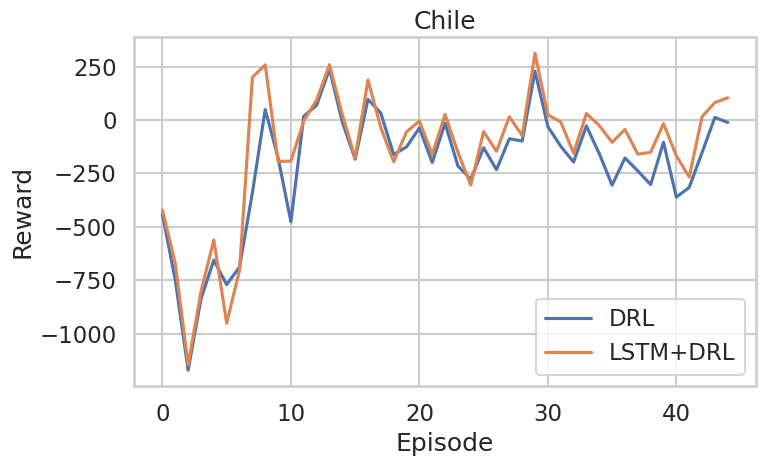

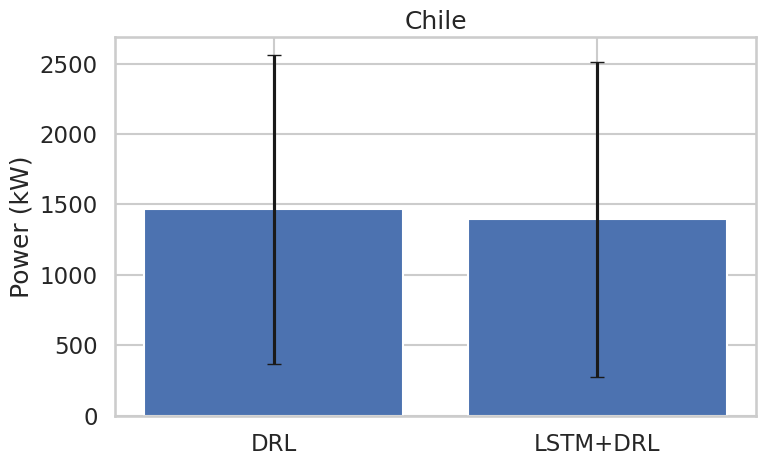

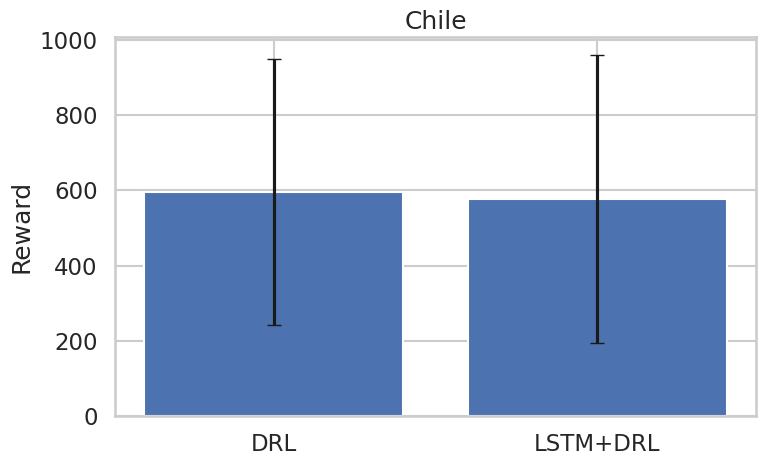

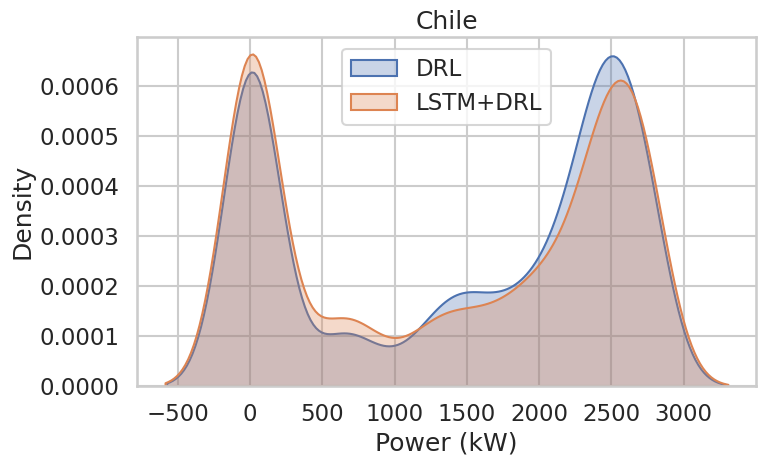

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


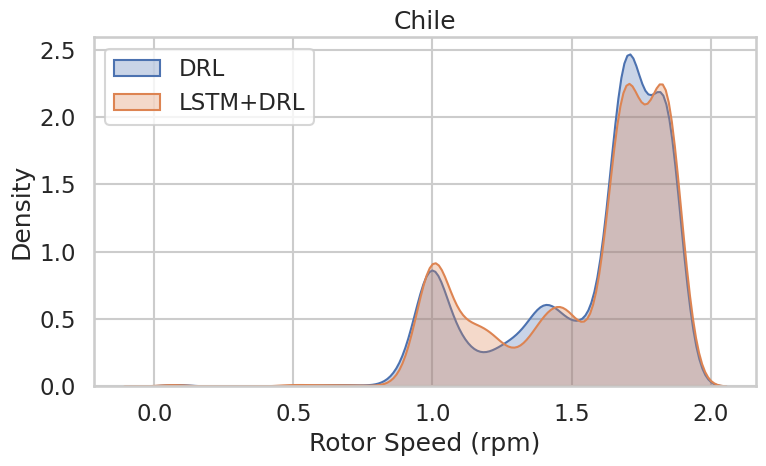

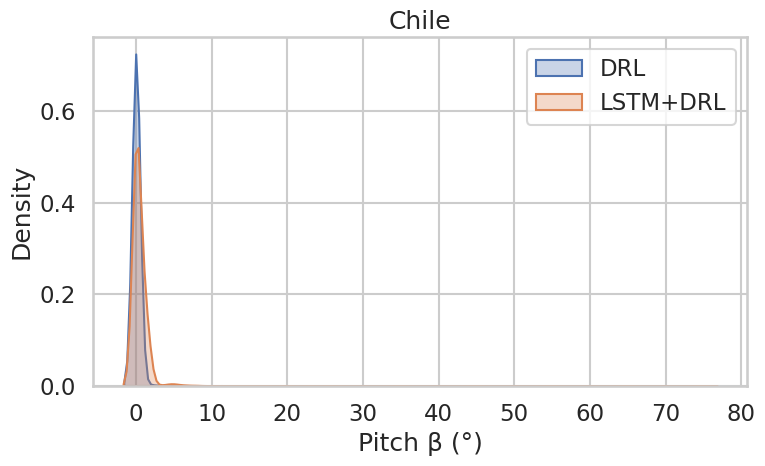

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


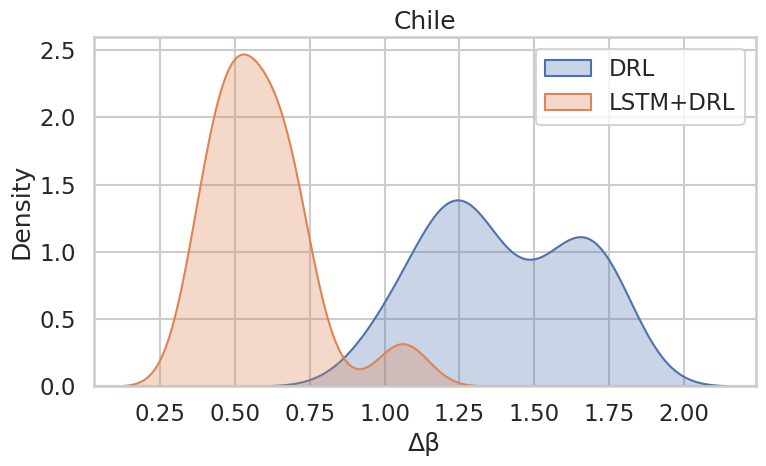

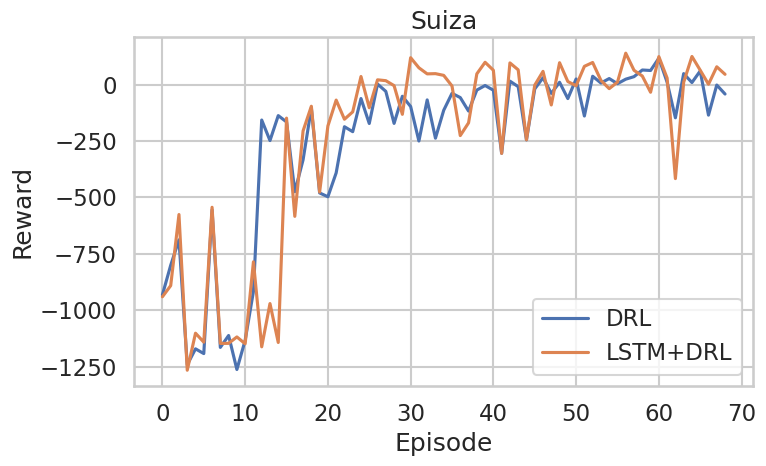

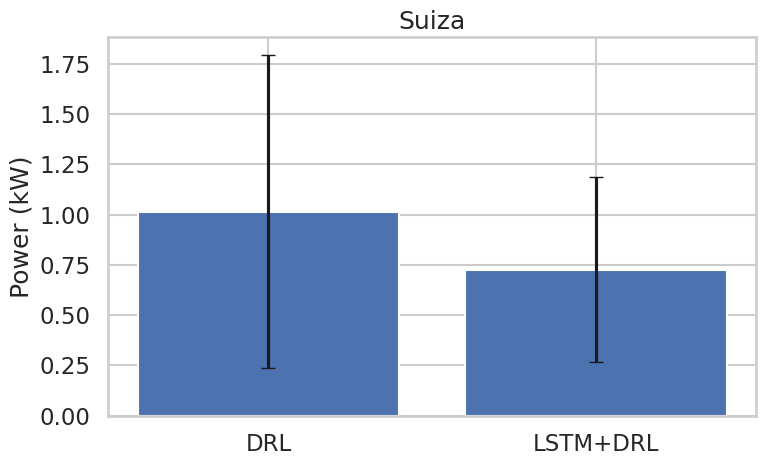

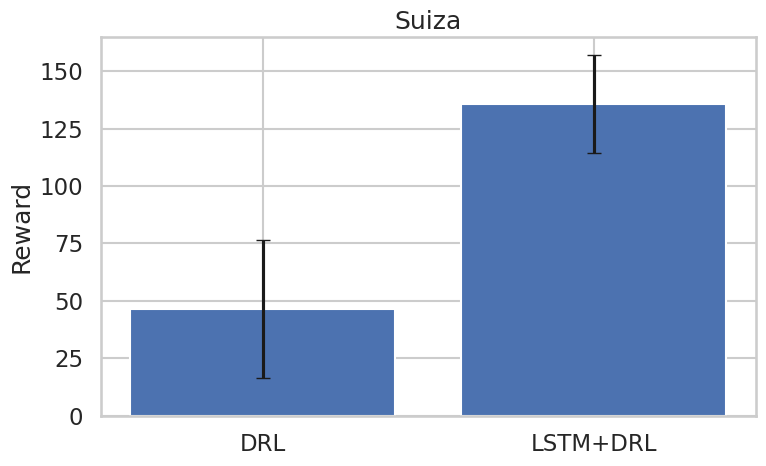

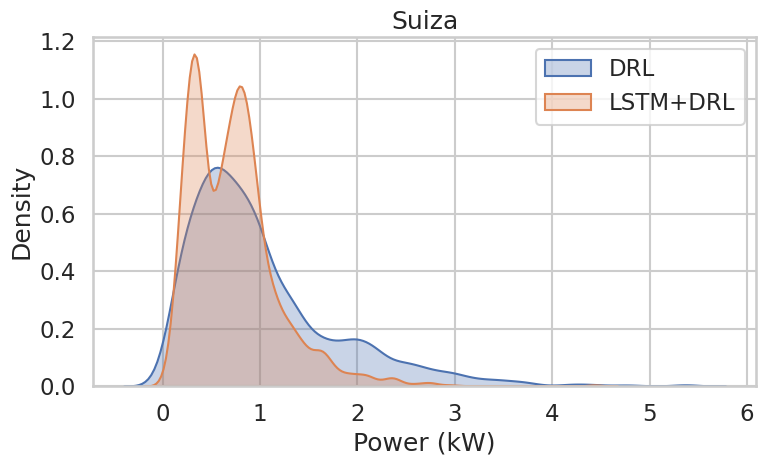

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


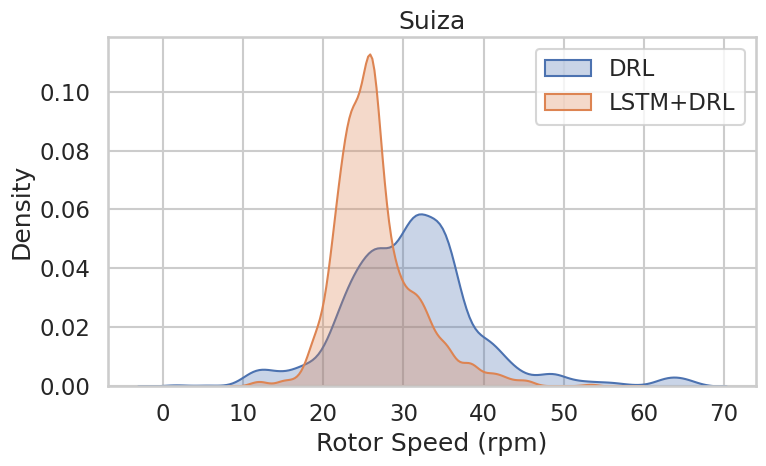

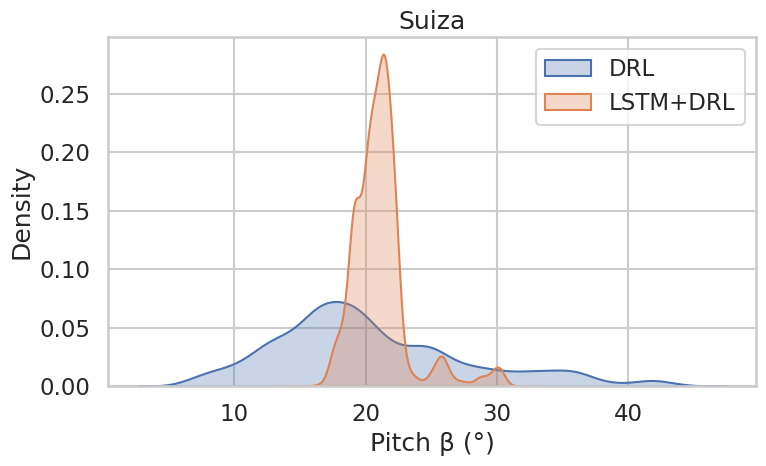

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


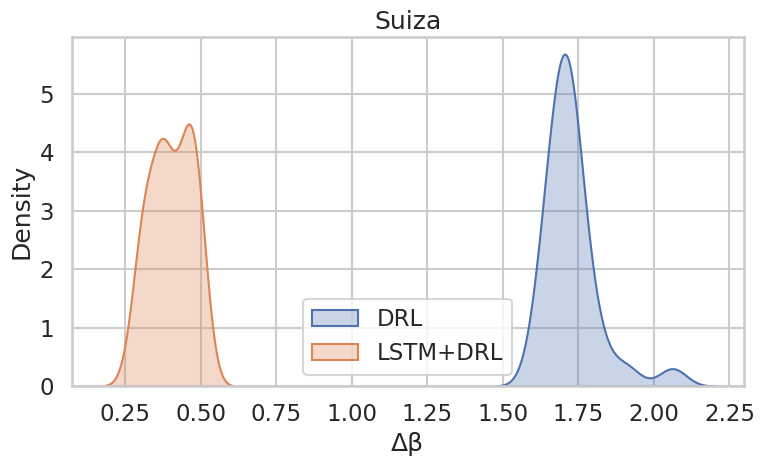

In [18]:
plot_country_analysis(models_chile, "Chile")
plot_country_analysis(models_suiza, "Suiza")

In [3]:
def plot_learning_curve_with_test(models, country_name):

    plt.figure(figsize=(9,6))

    for name, m in models.items():

        rewards = np.array(m['training']['episode_rewards'])
        episodes = np.arange(1, len(rewards)+1)

        # suavizado
        window = max(10, len(rewards)//20)
        smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')

        # reward test
        test_reward = m['test']['mean_reward_per_step']

        plt.plot(episodes, rewards, alpha=0.15)
        plt.plot(episodes[:len(smooth)], smooth, linewidth=2.5, label=f"{name} train")

        # línea reward test
        plt.axhline(
            test_reward,
            linestyle="--",
            linewidth=2,
            label=f"{name} test ≈ {test_reward:.1f}"
        )

    plt.title(f"{country_name}")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"learning_curve_test_{country_name}.png", dpi=300)
    plt.show()

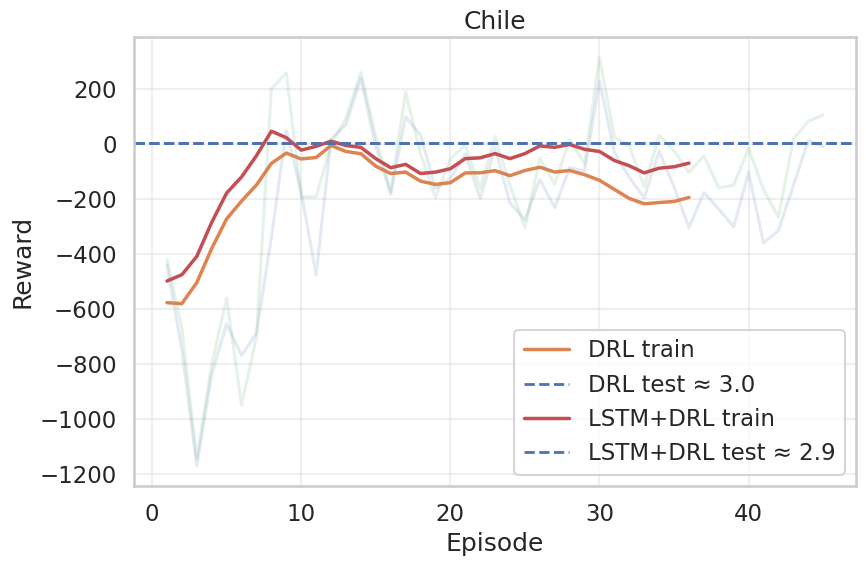

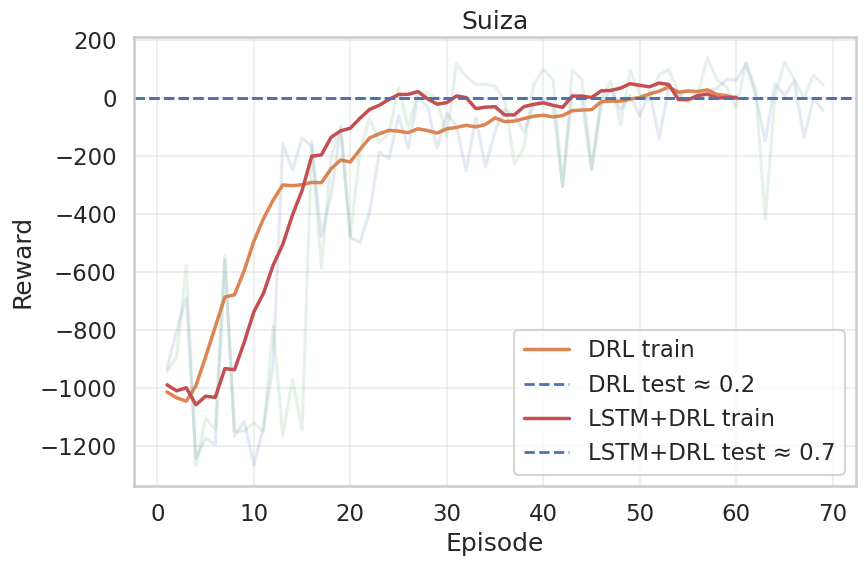

In [20]:
plot_learning_curve_with_test(models_chile, "Chile")
plot_learning_curve_with_test(models_suiza, "Suiza")


===== SANITY CHECK ====

DRL_Chile
Test reward: 596.1739307438347
Power mean: 1464.7623734524384
Omega mean: 1.5637934959848372
Beta mean: 0.25251983039509107

LSTM_DRL_Chile
Test reward: 577.089156972155
Power mean: 1394.4299571453585
Omega mean: 1.5572113736356323
Beta mean: 0.6723658518333536

DRL_Suiza
Test reward: 46.396918053155545
Power mean: 1.0147514205824217
Omega mean: 30.999524266525327
Beta mean: 20.372275945081988

LSTM_DRL_Suiza
Test reward: 135.71494377993687
Power mean: 0.7269360016899011
Omega mean: 26.464009869266146
Beta mean: 21.107331593369125


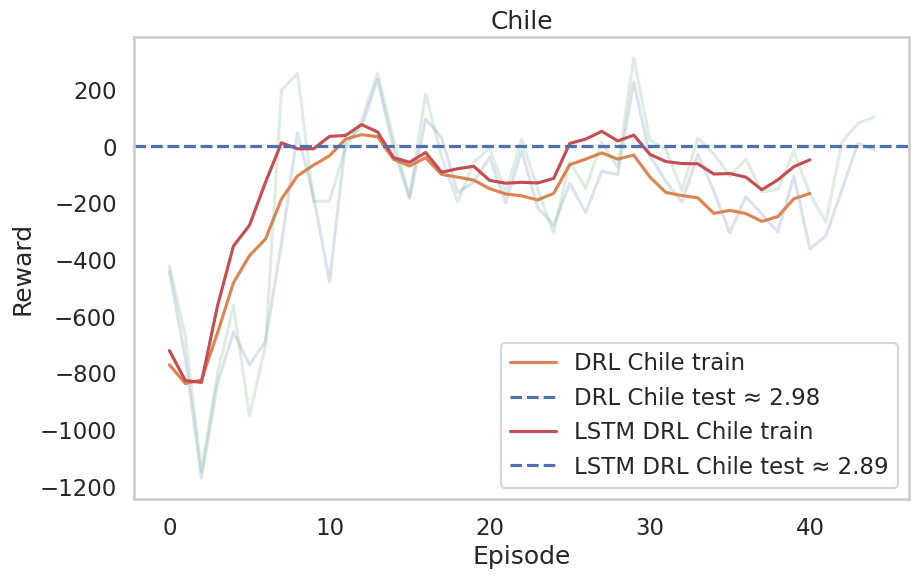

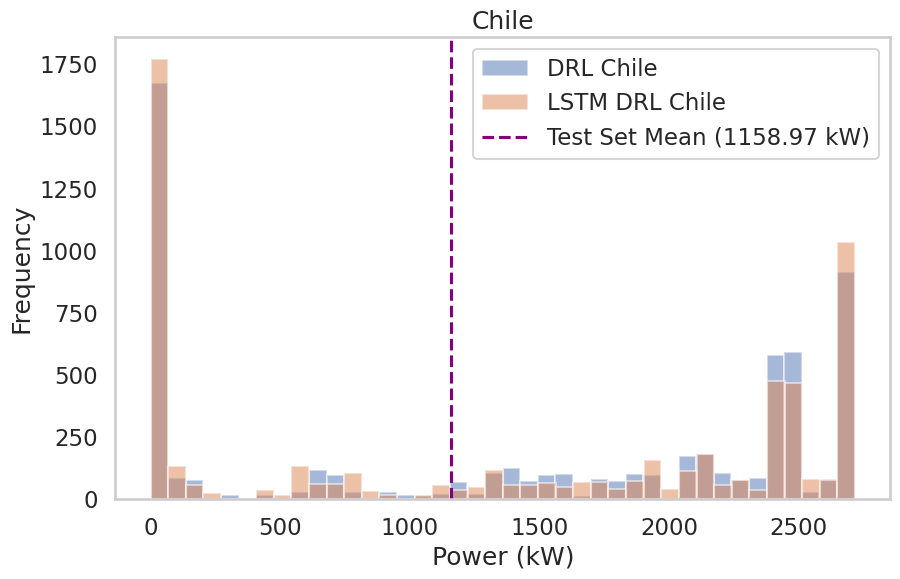

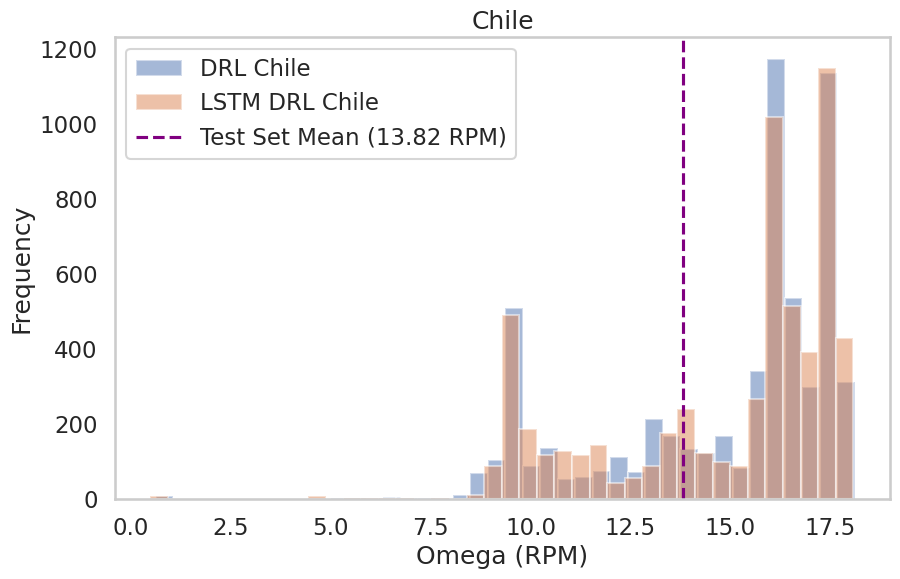

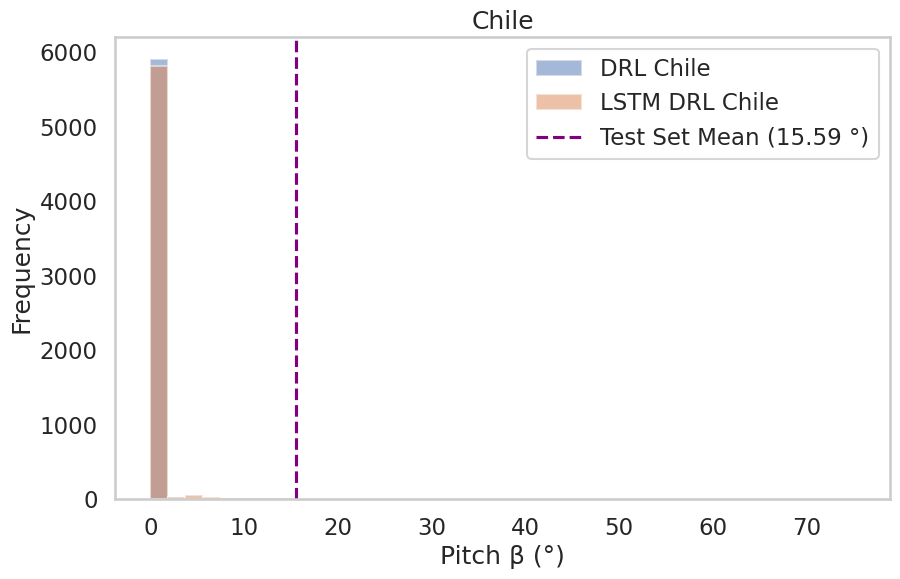

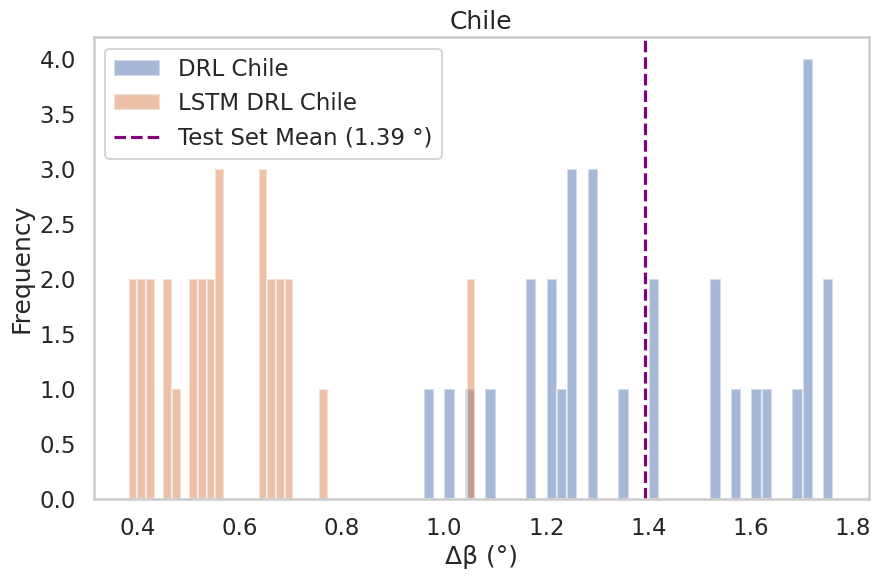

/tmp/ipykernel_498/3971116635.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


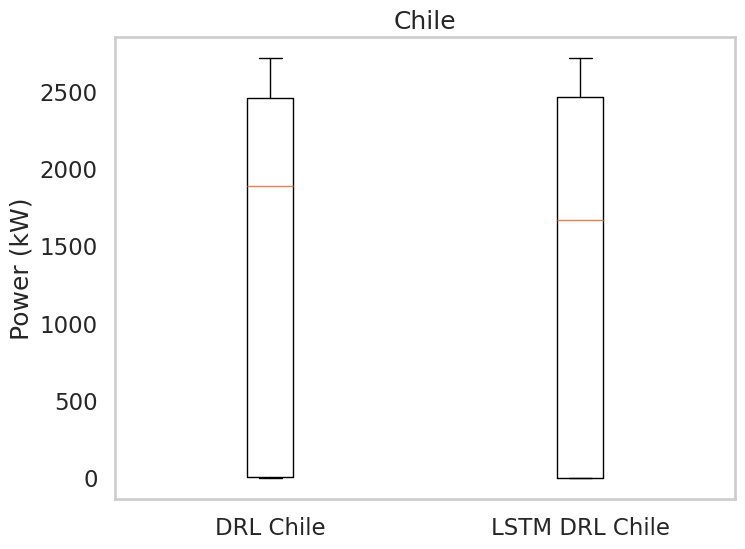

/tmp/ipykernel_498/3971116635.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


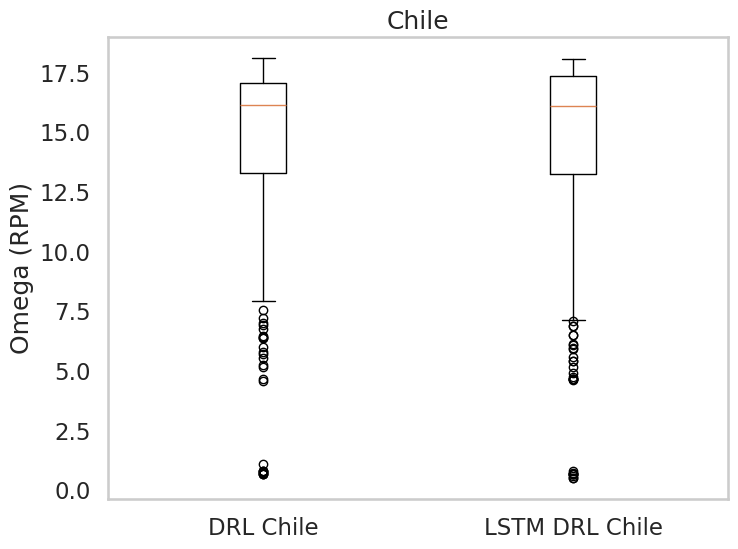

/tmp/ipykernel_498/3971116635.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


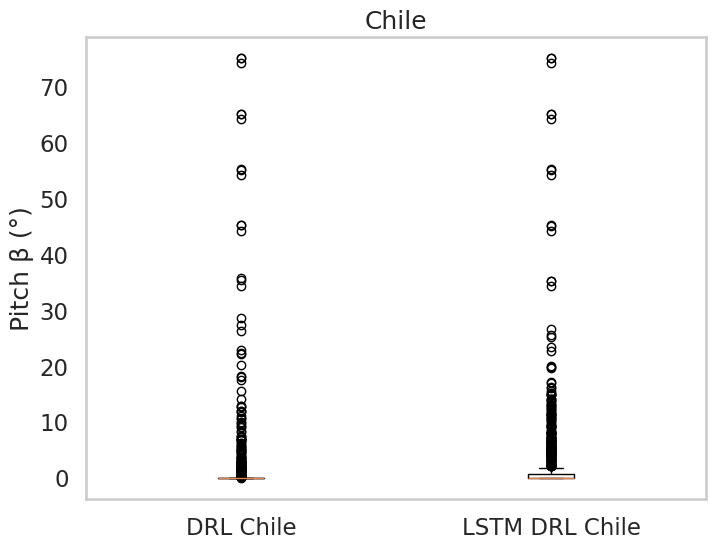

/tmp/ipykernel_498/3971116635.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


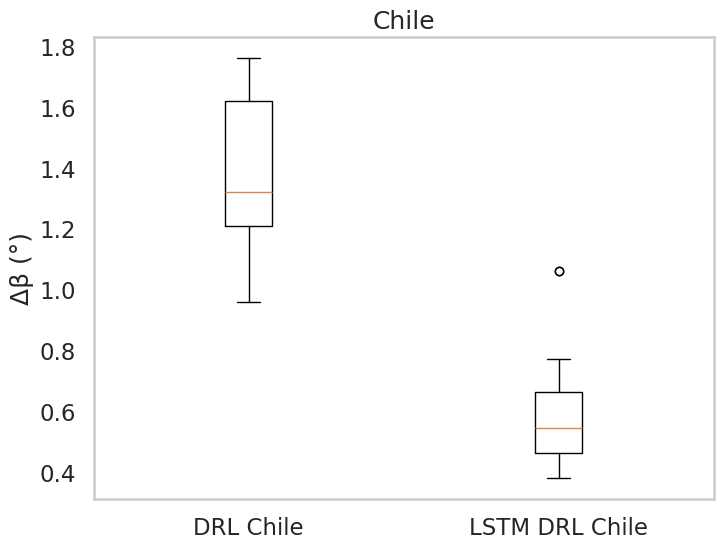

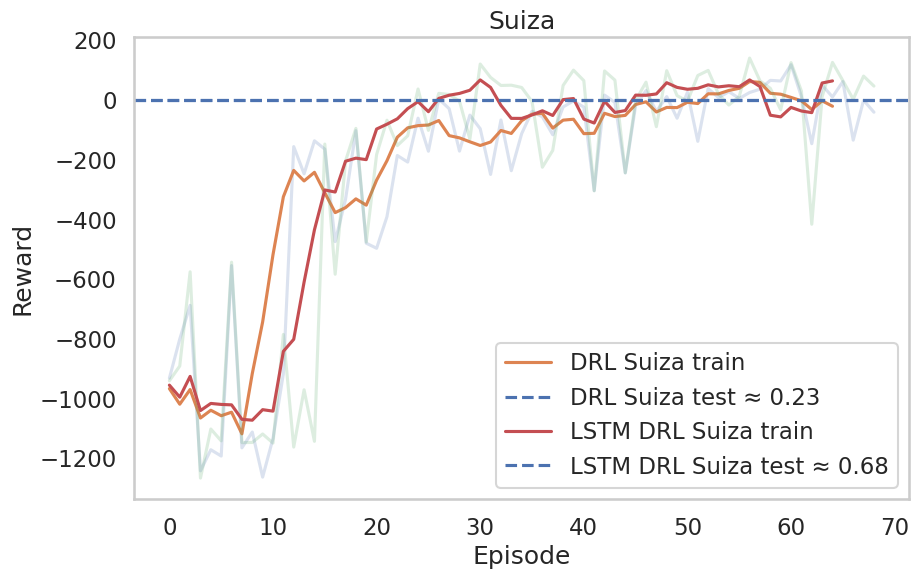

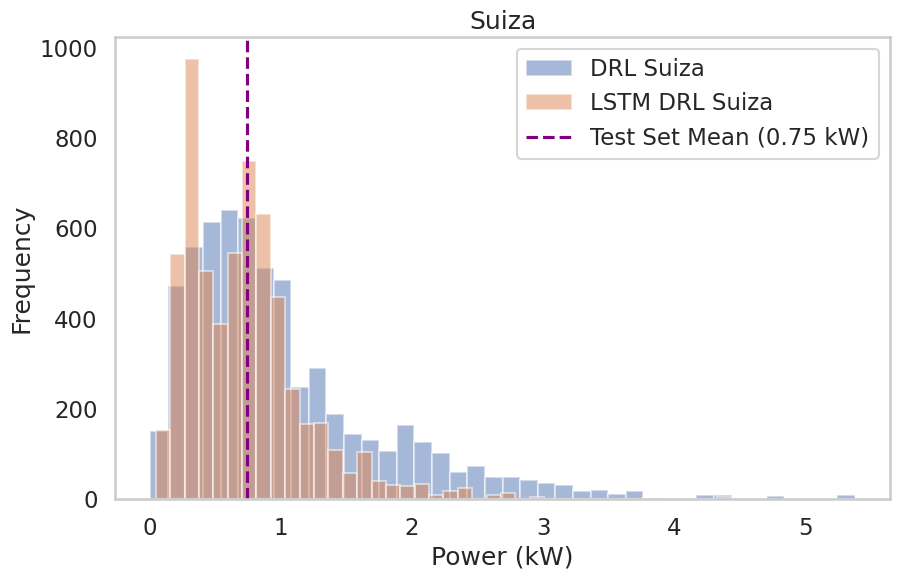

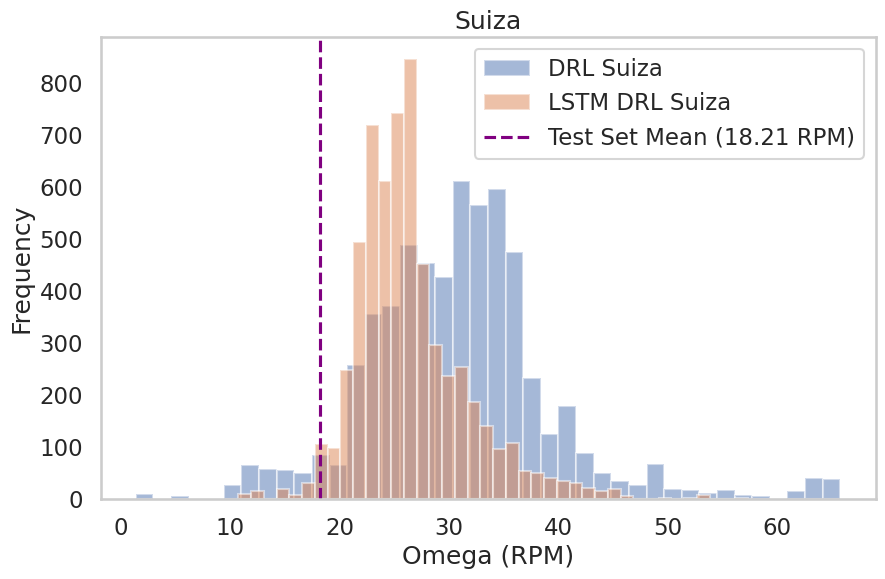

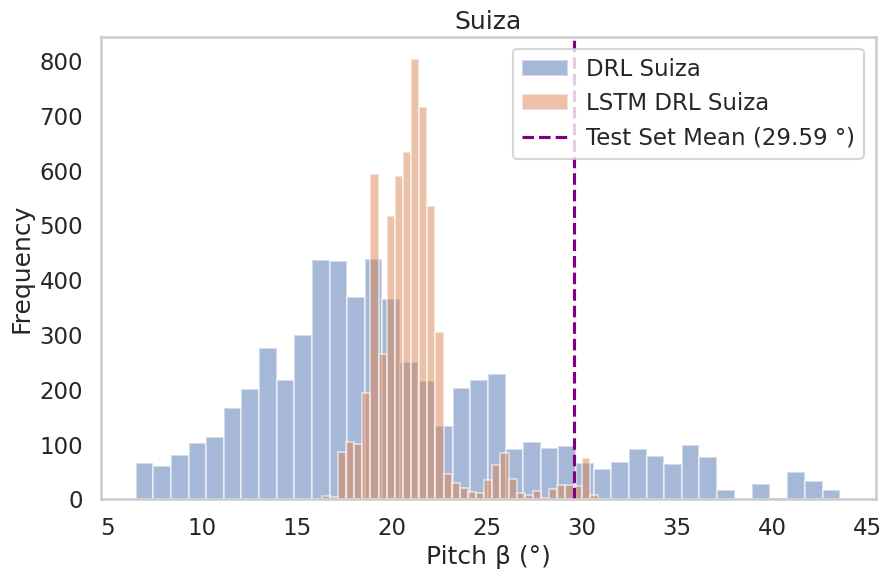

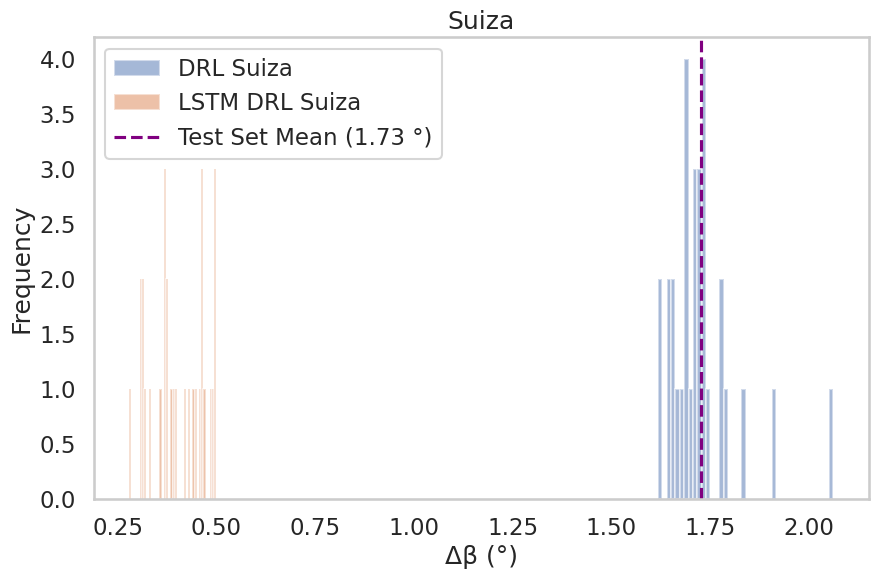

/tmp/ipykernel_498/3971116635.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


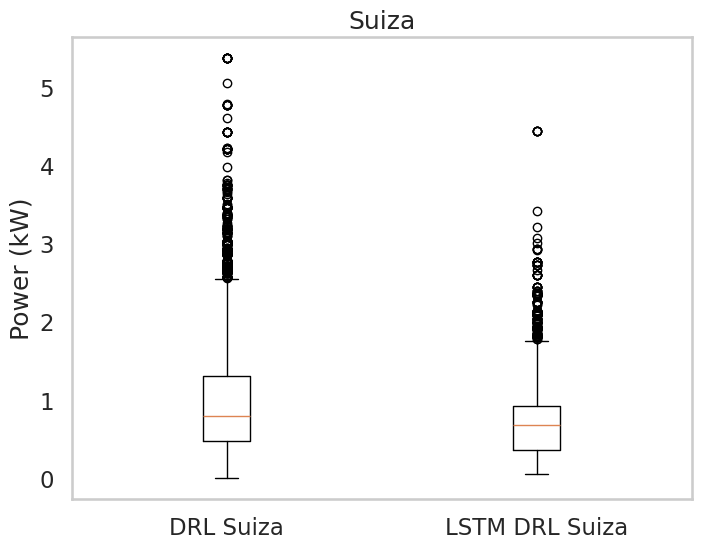

/tmp/ipykernel_498/3971116635.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


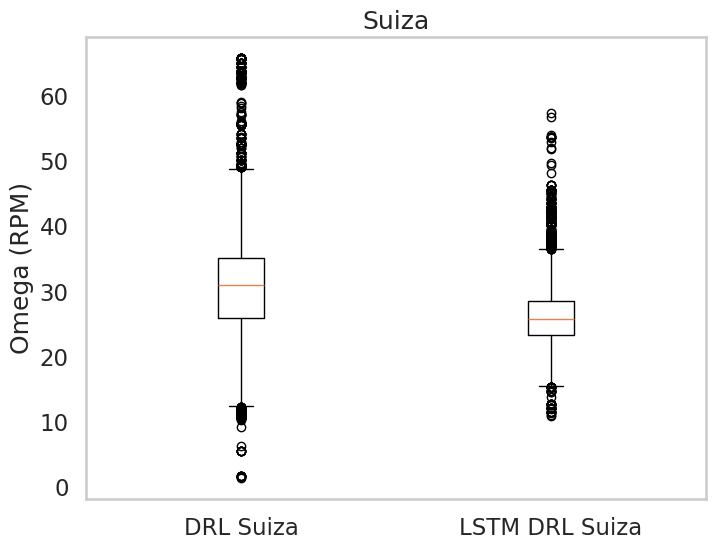

/tmp/ipykernel_498/3971116635.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


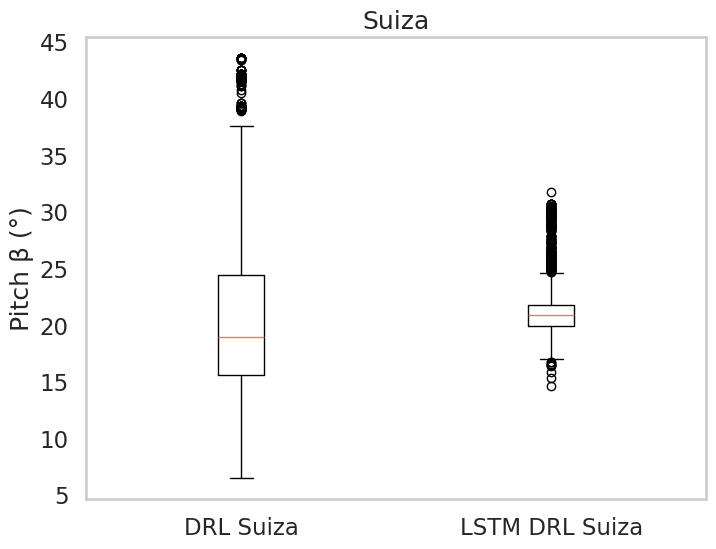

/tmp/ipykernel_498/3971116635.py:198: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


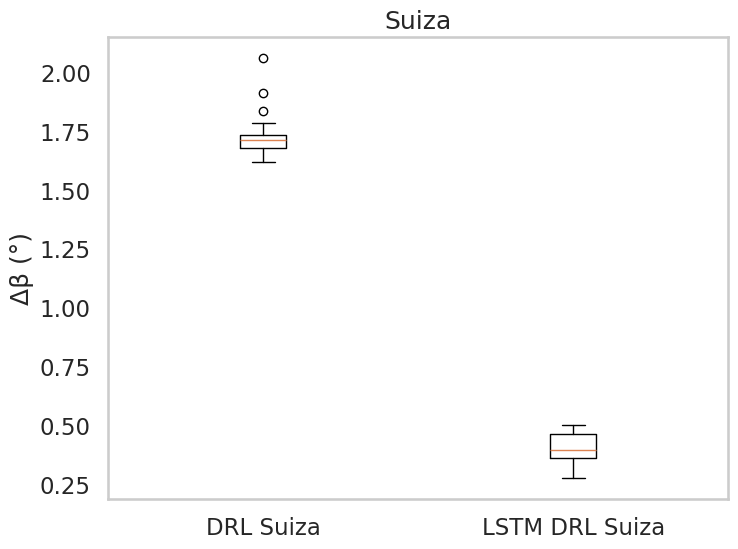


===== BOXPLOTS DE COMPARACIÓN GLOBAL ====


/tmp/ipykernel_498/3971116635.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


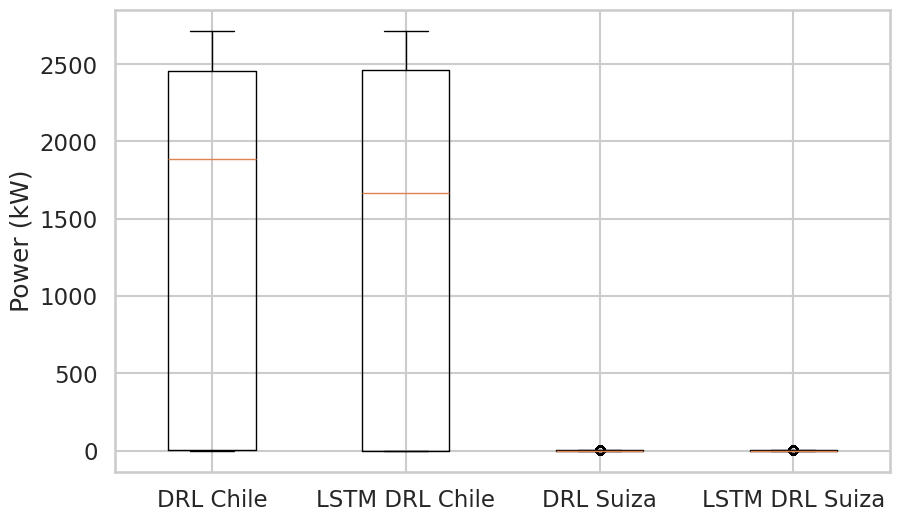

/tmp/ipykernel_498/3971116635.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


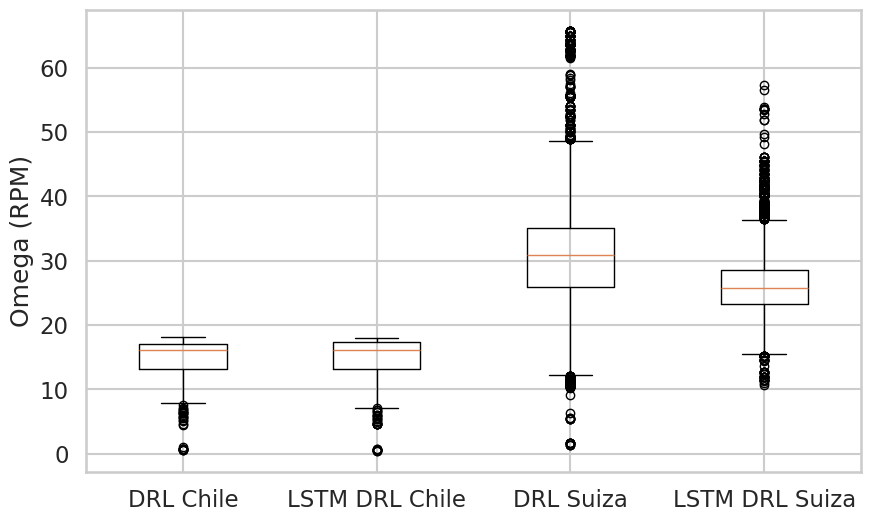

/tmp/ipykernel_498/3971116635.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


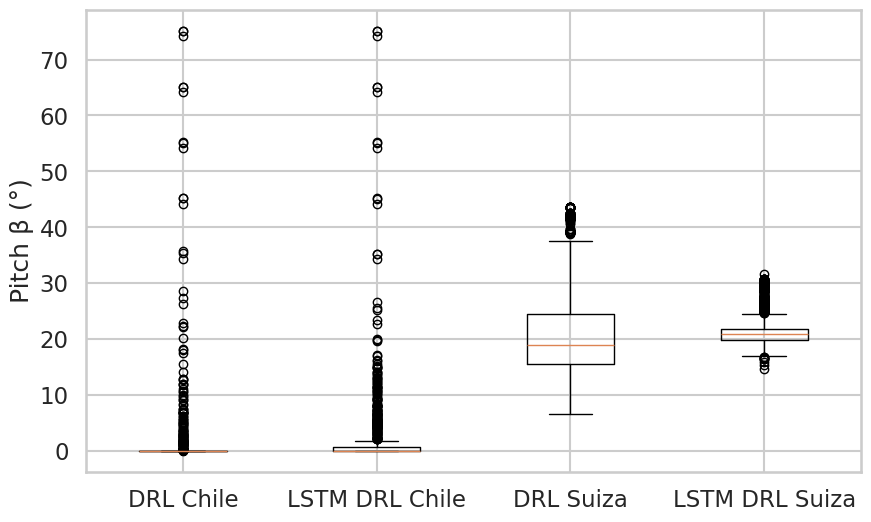

/tmp/ipykernel_498/3971116635.py:264: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_boxplot, labels=labels)


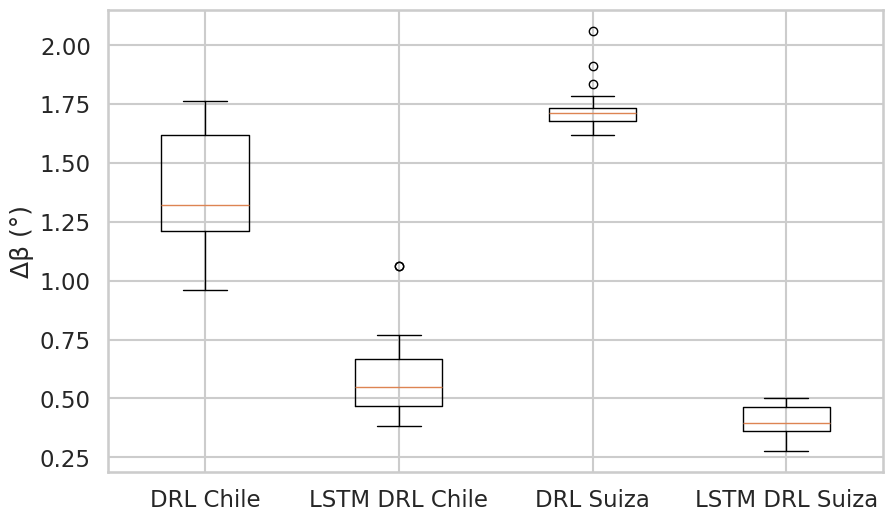


===== CUADRO COMPARATIVO DE MÉTRICAS CLAVE ====
| Model                                     |   Potencia Promedio (kW) | Desv. Est. Omega (RPM)   | Media Δβ (°)   | Índice Potencia/Omega (kW/RPM)   | Índice Potencia/Δβ (kW/°)   |
|:------------------------------------------|-------------------------:|:-------------------------|:---------------|:---------------------------------|:----------------------------|
| DRL Chile                                 |                  1464.76 | 2.86                     | 1.39           | 511.65                           | 1051.68                     |
| LSTM DRL Chile                            |                  1394.43 | 2.93                     | 0.59           | 475.71                           | 2381.31                     |
| DRL Suiza                                 |                     1.01 | 8.61                     | 1.73           | 0.12                             | 0.59                        |
| LSTM DRL Suiza                         

In [26]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ==============================
# CARGAR MODELOS
# ==============================

metrics_paths = {
    'DRL_Chile': '/content/drive/MyDrive/Tesis/Output/kNN_metrics_DRL_CL.pkl',
    'LSTM_DRL_Chile': '/content/drive/MyDrive/Tesis/Output/kNN_metrics_LSTMDRL_CL.pkl',
    'DRL_Suiza': '/content/drive/MyDrive/Tesis/Output/kNN_metrics_DRLSW.pkl',
    'LSTM_DRL_Suiza': '/content/drive/MyDrive/Tesis/Output/kNN_metrics_LSTMDRLSW.pkl',
}

models = {}

for name, path in metrics_paths.items():
    with open(path, 'rb') as f:
        models[name] = pickle.load(f)

# ==============================
# SANITY CHECK
# ==============================

print("\n===== SANITY CHECK ====")

for name, m in models.items():
    print(f"\n{name}")
    print("Test reward:", m['test']['mean_reward'])
    print("Power mean:", np.mean(m['test']['all_powers']))
    print("Omega mean:", np.mean(m['test']['all_omegas']))
    print("Beta mean:", np.mean(m['test']['all_betas']))

# ==============================
# SEPARAR PAISES
# ==============================

models_chile = {k:v for k,v in models.items() if "Chile" in k}
models_suiza = {k:v for k,v in models.items() if "Suiza" in k}

# ==============================
# FUNCION SMOOTH
# ==============================

def smooth_curve(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode='valid')

# ==============================
# LEARNING CURVES
# ==============================

def plot_learning_curves(models_dict, title):

    plt.figure(figsize=(10,6))

    for name, m in models_dict.items():

        rewards = m['training']['episode_rewards']
        smooth = smooth_curve(rewards)

        test_reward = m['test']['mean_reward_per_step']

        label = name.replace("_"," ")

        plt.plot(
            rewards,
            alpha=0.2
        )
        plt.plot(
            range(len(smooth)),
            smooth,
            label=f"{label} train"
        )

        plt.axhline(
            test_reward,
            linestyle="--",
            label=f"{label} test \u2248 {test_reward:.2f}"
        )

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid()
    plt.show()

# ==============================
# DISTRIBUTION PLOTS
# ==============================

def plot_distribution(models_dict, variable, title, original_xlabel): # Renamed xlabel for clarity
    plt.figure(figsize=(10,6))
    final_xlabel = original_xlabel # This will hold the label for the plot, updated dynamically

    conversion_factor_omega = 60 / (2 * np.pi) # rad/s to RPM
    # conversion_factor_pitch = 180 / np.pi # radians to degrees

    # Get the first model's dataset params to extract global mean for the test set
    # Assuming all models are evaluated on the same test set, these global means are consistent.
    first_model_name = list(models_dict.keys())[0]
    first_model = models_dict[first_model_name]

    mean_val = None
    mean_label_suffix = ""

    if variable == 'all_omegas':
        final_xlabel = "Omega (RPM)" # Update the final xlabel
        if 'Chile' in first_model_name: # Check if the first model is from Chile for conversion
            mean_val = first_model['dataset_params']['omega_mean_test'] * conversion_factor_omega
            mean_label_suffix = f'Mean Test Omega ({mean_val:.2f} RPM)'
        else: # For Suiza, assume it's already in RPM (no conversion needed)
            mean_val = first_model['dataset_params']['omega_mean_test']
            mean_label_suffix = f'Mean Test Omega ({mean_val:.2f} RPM)'
    elif variable == 'all_powers':
        final_xlabel = "Power (kW)" # Update the final xlabel
        mean_val = first_model['dataset_params']['P_mean_test']
        mean_label_suffix = f'Mean Test Power ({mean_val:.2f} kW)'
    elif variable == 'all_betas':
        final_xlabel = "Pitch \u03B2 (\u00B0)" # Update the final xlabel
        # if 'Chile' in first_model_name: # No conversion needed now
        #     mean_val = first_model['dataset_params']['pitch_mean_test'] * conversion_factor_pitch
        #     mean_label_suffix = f'Mean Test Beta ({mean_val:.2f} \u00B0)'
        # else:
        mean_val = first_model['dataset_params']['pitch_mean_test']
        mean_label_suffix = f'Mean Test Beta ({mean_val:.2f} \u00B0)'
    elif variable == 'all_deltas': # Add this for delta distributions
        final_xlabel = "\u0394\u03B2 (\u00B0)"
        # Mean delta is not stored in dataset_params, so we'll calculate from the model's test results
        mean_val = np.mean(first_model['test']['all_deltas'])
        mean_label_suffix = f'Mean Test \u0394\u03B2 ({mean_val:.2f} \u00B0)'

    for name, m in models_dict.items():
        data = np.array(m['test'][variable])

        if variable == 'all_omegas' and 'Chile' in name:
            data = data * conversion_factor_omega
        # elif variable == 'all_betas' and 'Chile' in name: # No conversion needed now
        #     data = data * conversion_factor_pitch

        plt.hist(
            data,
            bins=40,
            alpha=0.5,
            density=False, # Changed to False for frequency
            label=name.replace("_"," ")
        )

    # Plot the global mean line only once outside the loop
    if mean_val is not None:
        plt.axvline(mean_val, color='purple', linestyle='--', label=f'Test Set Mean ({mean_label_suffix.split("(")[1]}') # Extract value from suffix for legend

    plt.title(title)
    plt.xlabel(final_xlabel) # Use the dynamically determined xlabel
    plt.ylabel("Frequency") # Changed ylabel to Frequency
    plt.legend()
    plt.grid()
    plt.show()

# ==============================
# BOX PLOTS (MUY BUENOS PARA TESIS)
# ==============================

def plot_box(models_dict, variable, title, original_ylabel): # Renamed ylabel for clarity

    data_for_boxplot = []
    labels = []
    final_ylabel = original_ylabel # This will hold the label for the plot, updated dynamically

    conversion_factor_omega = 60 / (2 * np.pi)
    # conversion_factor_pitch = 180 / np.pi

    for name, m in models_dict.items():
        current_data = np.array(m['test'][variable])

        # Conditional unit conversion for 'all_omegas'
        if variable == 'all_omegas':
            final_ylabel = "Omega (RPM)" # Update the final ylabel
            if 'Chile' in name:
                current_data = current_data * conversion_factor_omega # Convert rad/s to RPM
            # No conversion needed for Suiza, as it's assumed to be RPM in the raw data
        elif variable == 'all_powers':
            final_ylabel = "Power (kW)"
        elif variable == 'all_betas':
            final_ylabel = "Pitch \u03B2 (\u00B0)"
            # if 'Chile' in name: # No conversion needed now
            #     current_data = current_data * conversion_factor_pitch # Convert radians to degrees
        elif variable == 'all_deltas': # Add this for delta boxplots
            final_ylabel = "\u0394\u03B2 (\u00B0)"

        data_for_boxplot.append(current_data)
        labels.append(name.replace("_"," "))

    plt.figure(figsize=(8,6))
    plt.boxplot(data_for_boxplot, labels=labels)
    plt.title(title)
    plt.ylabel(final_ylabel) # Use the dynamically determined ylabel
    plt.grid()
    plt.show()

def plot_combined_boxplots(models_dict, country_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
    fig.suptitle(f'Boxplots for {country_name}', fontsize=16)

    variables = ['all_powers', 'all_omegas', 'all_betas']
    ylabels = ['Power (kW)', 'Omega (RPM)', 'Pitch \u03B2 (\u00B0)']
    conversion_factor_omega = 60 / (2 * np.pi)
    # conversion_factor_pitch = 180 / np.pi

    for i, variable in enumerate(variables):
        data_for_boxplot = []
        labels = []
        current_ylabel = ylabels[i]

        for name, m in models_dict.items():
            current_data = np.array(m['test'][variable])

            if variable == 'all_omegas' and 'Chile' in name:
                current_data = current_data * conversion_factor_omega
            # elif variable == 'all_betas' and 'Chile' in name: # No conversion needed now
            #     current_data = current_data * conversion_factor_pitch

            data_for_boxplot.append(current_data)
            labels.append(name.replace("_", " "))

        axes[i].boxplot(data_for_boxplot, labels=labels)
        axes[i].set_title(f'{current_ylabel} Distribution')
        axes[i].set_ylabel(current_ylabel)
        axes[i].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_comparison_boxplots(all_models_dict, variable, title, original_ylabel):
    plt.figure(figsize=(10, 6))
    data_for_boxplot = []
    labels = []
    final_ylabel = original_ylabel
    conversion_factor_omega = 60 / (2 * np.pi)
    # conversion_factor_pitch = 180 / np.pi

    for name, m in all_models_dict.items():
        current_data = np.array(m['test'][variable])

        if variable == 'all_omegas':
            final_ylabel = "Omega (RPM)"
            if 'Chile' in name:
                current_data = current_data * conversion_factor_omega
        elif variable == 'all_powers':
            final_ylabel = "Power (kW)"
        elif variable == 'all_betas':
            final_ylabel = "Pitch \u03B2 (\u00B0)"
            # if 'Chile' in name: # No conversion needed now
            #     current_data = current_data * conversion_factor_pitch
        elif variable == 'all_deltas':
            final_ylabel = "\u0394\u03B2 (\u00B0)"

        data_for_boxplot.append(current_data)
        labels.append(name.replace("_", " "))

    plt.boxplot(data_for_boxplot, labels=labels)
    plt.ylabel(final_ylabel)
    plt.grid(True)
    plt.show()

# ==============================
# GENERAR FIGURAS CHILE
# ==============================

plot_learning_curves(
    models_chile,
    "Chile"
)

plot_distribution(
    models_chile,
    'all_powers',
    "Chile",
    "Power (kW)"
)

plot_distribution(
    models_chile,
    'all_omegas',
    "Chile",
    "Omega (RPM)"
)

plot_distribution(
    models_chile,
    'all_betas',
    "Chile",
    "Pitch \u03B2 (\u00B0)"
)

plot_distribution(
    models_chile,
    'all_deltas',
    "Chile",
    "\u0394\u03B2 (\u00B0)"
)

plot_box(
    models_chile,
    'all_powers',
    "Chile",
    "Power (kW)"
)

plot_box(
    models_chile,
    'all_omegas',
    "Chile",
    "Omega (RPM)"
)

plot_box(
    models_chile,
    'all_betas',
    "Chile",
    "Pitch \u03B2 (\u00B0)"
)

plot_box(
    models_chile,
    'all_deltas',
    "Chile",
    "\u0394\u03B2 (\u00B0)"
)

# ==============================
# GENERAR FIGURAS SUIZA
# ==============================

plot_learning_curves(
    models_suiza,
    "Suiza"
)

plot_distribution(
    models_suiza,
    'all_powers',
    "Suiza",
    "Power (kW)"
)

plot_distribution(
    models_suiza,
    'all_omegas',
    "Suiza",
    "Omega (RPM)"
)

plot_distribution(
    models_suiza,
    'all_betas',
    "Suiza",
    "Pitch \u03B2 (\u00B0)"
)

plot_distribution(
    models_suiza,
    'all_deltas',
    "Suiza",
    "\u0394\u03B2 (\u00B0)"
)

plot_box(
    models_suiza,
    'all_powers',
    "Suiza",
    "Power (kW)"
)

plot_box(
    models_suiza,
    'all_omegas',
    "Suiza",
    "Omega (RPM)"
)

plot_box(
    models_suiza,
    'all_betas',
    "Suiza",
    "Pitch \u03B2 (\u00B0)"
)

plot_box(
    models_suiza,
    'all_deltas',
    "Suiza",
    "\u0394\u03B2 (\u00B0)"
)

# ==============================
# GENERAR FIGURAS DE COMPARACIÓN GLOBAL (CUATRO MODELOS)
# ==============================

print("\n===== BOXPLOTS DE COMPARACIÓN GLOBAL ====")

plot_comparison_boxplots(
    models,
    'all_powers',
    "Global Power Distribution Comparison",
    "Power (kW)"
)

plot_comparison_boxplots(
    models,
    'all_omegas',
    "Global Omega Distribution Comparison",
    "Omega (RPM)"
)

plot_comparison_boxplots(
    models,
    'all_betas',
    "Global Pitch Distribution Comparison",
    "Pitch \u03B2 (\u00B0)"
)

plot_comparison_boxplots(
    models,
    'all_deltas',
    "Global \u0394\u03B2 Distribution Comparison",
    "\u0394\u03B2 (\u00B0)"
)


# ==============================
# CUADRO COMPARATIVO DE MÉTRICAS CLAVE
# ==============================

print("\n===== CUADRO COMPARATIVO DE MÉTRICAS CLAVE ====")

summary_data = []
conversion_factor_omega = 60 / (2 * np.pi) # For converting rad/s to RPM

for name, m in models.items():
    mean_power = np.mean(m['test']['all_powers'])

    std_omega = np.std(m['test']['all_omegas'])
    if 'Chile' in name:
        std_omega = std_omega * conversion_factor_omega # Convert to RPM for Chile

    mean_delta_beta = np.mean(m['test']['all_deltas'])

    # Calculate commitment indices
    power_omega_index = mean_power / std_omega if std_omega != 0 else np.nan
    power_deltas_index = mean_power / mean_delta_beta if mean_delta_beta != 0 else np.nan

    summary_data.append({
        'Model': name.replace('_', ' '),
        'Potencia Promedio (kW)': f'{mean_power:.2f}',
        'Desv. Est. Omega (RPM)': f'{std_omega:.2f}',
        'Media \u0394\u03B2 (\u00B0)': f'{mean_delta_beta:.2f}',
        'Índice Potencia/Omega (kW/RPM)': f'{power_omega_index:.2f}',
        'Índice Potencia/\u0394\u03B2 (kW/\u00B0)': f'{power_deltas_index:.2f}'
    })

# Calculate Relative Power Efficiency
drl_chile_power = np.mean(models['DRL_Chile']['test']['all_powers'])
lstm_drl_chile_power = np.mean(models['LSTM_DRL_Chile']['test']['all_powers'])
relative_efficiency_chile = (lstm_drl_chile_power / drl_chile_power) * 100

drl_suiza_power = np.mean(models['DRL_Suiza']['test']['all_powers'])
lstm_drl_suiza_power = np.mean(models['LSTM_DRL_Suiza']['test']['all_powers'])
relative_efficiency_suiza = (lstm_drl_suiza_power / drl_suiza_power) * 100

summary_data.append({
    'Model': 'Eficiencia Relativa de Potencia Chile (%)',
    'Potencia Promedio (kW)': f'{relative_efficiency_chile:.2f}',
    'Desv. Est. Omega (RPM)': '',
    'Media \u0394\u03B2 (\u00B0)': '',
    'Índice Potencia/Omega (kW/RPM)': '',
    'Índice Potencia/\u0394\u03B2 (kW/\u00B0)': ''
})
summary_data.append({
    'Model': 'Eficiencia Relativa de Potencia Suiza (%)',
    'Potencia Promedio (kW)': f'{relative_efficiency_suiza:.2f}',
    'Desv. Est. Omega (RPM)': '',
    'Media \u0394\u03B2 (\u00B0)': '',
    'Índice Potencia/Omega (kW/RPM)': '',
    'Índice Potencia/\u0394\u03B2 (kW/\u00B0)': ''
})

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.set_index('Model')

print(df_summary.to_markdown())

print("\n==============================================")
print("✅ GENERACIÓN DE GRÁFICOS Y CUADRO COMPLETADO")
print("==============================================")
